# Zadanie 4: Optymalizacja modeli operujących na danych grafowych

### autor: Paweł Gleindek (CWL02 - wtorek 9:45)

Tematem czwartego zadania zaliczeniowego jest optymalizacja modeli operujących na danych grafowych (tj. składających się z węzłów połączonych krawędziami). W swoim projekcie wybrałem zbiór **OGBN-ArXiv** dostępny na [platformie Kaggle](https://www.kaggle.com/datasets/dataup1/ogbn-arxiv).

**Podstawowa charakterystyka zbioru danych:**

- wierzchołki: artykuły (ok. 169 tysięcy)
- krawędzie: cytowania między artykułami (ok. 1.1 miliona)
- cechy wierzchołków: 128-wymiarowe wektory
- zadanie: klasyfikacja wierzchołków - przewidywanie jednej z 40 kategorii tematycznych artykułu

Zbiór ten z jednej strony jest wystarczająco duży i złożony, aby pokazać wyższość modeli grafowych nad klasycznymi metodami uczenia maszynowego, a z drugiej wystarczająco mały, aby treningowi podołała moja karta graficzna. Na pewno nie jest też zbiorem, który od 1 modelu da 90% *accuracy* - obecnie najlepsze światowe modele osiągnęły wynik 77.2% dokładności na zbiorze testowym. Pokazuje to złożoność zadania i konieczność doboru odpowiednich struktur sieci i strojenia hiperparametrów.


## Instalacja i import niezbędnych bibliotek

Do uczenia głębokiego (sklearn, keras, tensorflow, pytorch), obróbki danych (numpy, pandas) oraz wizualizacji (matplotlib)

In [1]:
!pip install torch-geometric ogb --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 264.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 230.1 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 w

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from ogb.nodeproppred import PygNodePropPredDataset
import torch_geometric.transforms as T
import functools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GatedGraphConv, GATv2Conv
from torch.nn import Linear, LayerNorm, ReLU

## Załadowanie zbioru danych

In [4]:
if not hasattr(torch, '_custom_patch_applied'):
    orig_load = torch.load
    @functools.wraps(orig_load)
    def custom_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return orig_load(*args, **kwargs)
    
    torch.load = custom_load
    torch._custom_patch_applied = True

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/', transform=T.ToUndirected())

data = dataset[0]
split_idx = dataset.get_idx_split()

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:08<00:00,  9.33it/s]


Extracting dataset/arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 9137.92it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 396.85it/s]

Saving...



Done!


## EDA - eksploracyjna analiza danych

Standardowa procedura pozwalająca na lepsze zobrazowanie i zrozumienie struktury i zależności w wybranym zbiorze danych.

### 1. Podstawowa charakterystyka zbioru danych

Sprawdzenie liczby wierzchołków, krawędzi, klas.

In [11]:
print(f"Liczba wierzchołków (artykułów): {data.num_nodes}")
print(f"Liczba krawędzi (cytowań): {data.num_edges}")
print(f"Rozmiar wektora cech wierzchołka: {data.num_node_features}")
print(f"Liczba klas (kategorii tematycznych): {dataset.num_classes}")

Liczba wierzchołków (artykułów): 169343
Liczba krawędzi (cytowań): 2315598
Rozmiar wektora cech wierzchołka: 128
Liczba klas (kategorii tematycznych): 40


### 2. Podział danych na zbiór treningowy, walidacyjny i testowy

In [5]:
train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx = split_idx['test']

In [13]:
print(f"Wierzchołki treningowe: {len(train_idx)} ({len(train_idx)/data.num_nodes*100:.2f}%)")
print(f"Wierzchołki walidacyjne: {len(valid_idx)} ({len(valid_idx)/data.num_nodes*100:.2f}%)")
print(f"Wierzchołki testowe: {len(test_idx)} ({len(test_idx)/data.num_nodes*100:.2f}%)")

Wierzchołki treningowe: 90941 (53.70%)
Wierzchołki walidacyjne: 29799 (17.60%)
Wierzchołki testowe: 48603 (28.70%)


### 3. Statystyki stopni wierzchołków

Obliczanie stopnia każdego wierzchołka (liczby połączeń), wyznaczenie statystyk dotyczących stopni (`min, max, mean, med`).

In [14]:
row, col = data.edge_index
degrees = np.bincount(row.numpy(), minlength=data.num_nodes)

In [15]:
print(f"Maksymalny stopień wierzchołka: {degrees.max()}")
print(f"Minimalny stopień wierzchołka: {degrees.min()}")
print(f"Średni stopień wierzchołka: {degrees.mean():.2f}")
print(f"Mediana stopni wierzchołków: {np.median(degrees):.2f}")

Maksymalny stopień wierzchołka: 13161
Minimalny stopień wierzchołka: 1
Średni stopień wierzchołka: 13.67
Mediana stopni wierzchołków: 6.00


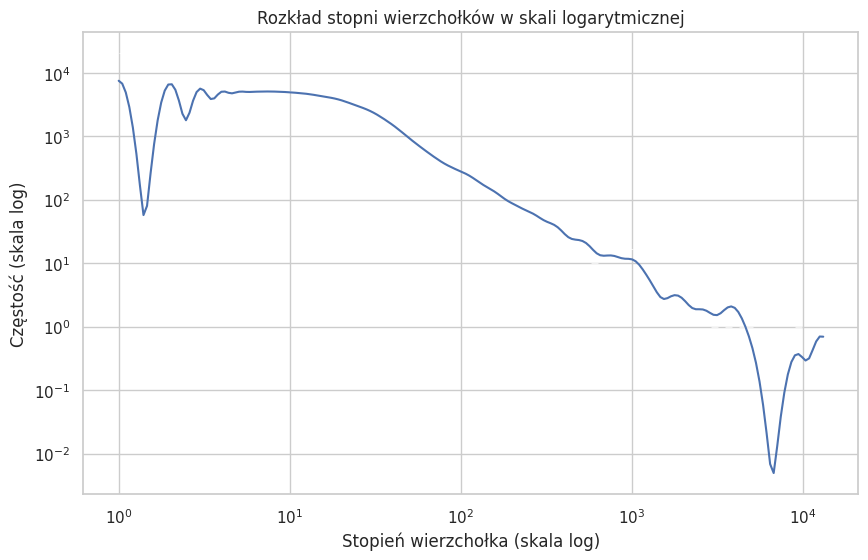

In [16]:
plt.figure()
sns.histplot(degrees, bins=100, kde=True, log_scale=(True, True))
plt.title("Rozkład stopni wierzchołków w skali logarytmicznej")
plt.xlabel("Stopień wierzchołka (skala log)")
plt.ylabel("Częstość (skala log)")
plt.show()

### 4. Analiza zbalansowania klas

In [17]:
labels = data.y.squeeze().numpy()
class_counts = pd.Series(labels).value_counts().sort_index()

In [18]:
print(f"Najliczniejsza klasa ma {class_counts.max()} artykułów.")
print(f"Najmniej liczna klasa ma {class_counts.min()} artykułów.")
print(f"Stosunek najliczniejszej do najmniej licznej: {class_counts.max() / class_counts.min():.2f}x")

Najliczniejsza klasa ma 27321 artykułów.
Najmniej liczna klasa ma 29 artykułów.
Stosunek najliczniejszej do najmniej licznej: 942.10x


/tmp/ipykernel_58/3367661909.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


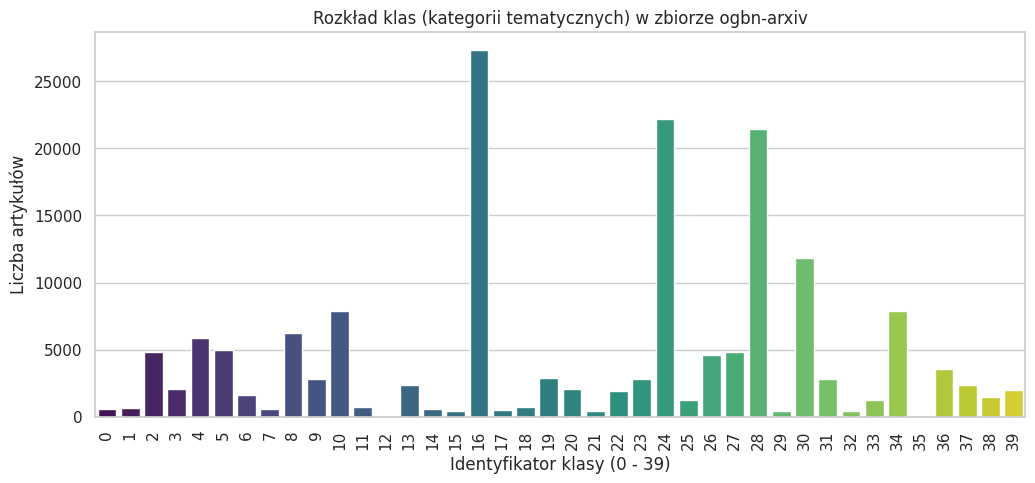

In [19]:
plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Rozkład klas (kategorii tematycznych) w zbiorze ogbn-arxiv")
plt.xlabel("Identyfikator klasy (0 - 39)")
plt.ylabel("Liczba artykułów")
plt.xticks(rotation=90)
plt.show()

### 5. Analiza Homofilii Grafu

Homofilia mierzy, jak często krawędzie łączą wierzchołki o tej samej klasie. Wartość bliska 1 oznacza, że sąsiedzi zazwyczaj należą do tej samej klasy.

In [20]:
edge_start_labels = labels[row.numpy()]
edge_end_labels = labels[col.numpy()]

In [21]:
same_class_edges = np.sum(edge_start_labels == edge_end_labels)
homophily_ratio = same_class_edges / data.num_edges
print(f"Wskaźnik homofilii (Homophily Ratio): {homophily_ratio:.4f}")
print("Interpretacja: Około {:.1f}% cytowań występuje w obrębie tej samej kategorii naukowej.".format(homophily_ratio * 100))

Wskaźnik homofilii (Homophily Ratio): 0.6542
Interpretacja: Około 65.4% cytowań występuje w obrębie tej samej kategorii naukowej.


### 6. Wizualizacja przestrzeni cech

Uruchamianie t-SNE dla 2000 losowych wierzchołków (to może chwilę potrwać)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


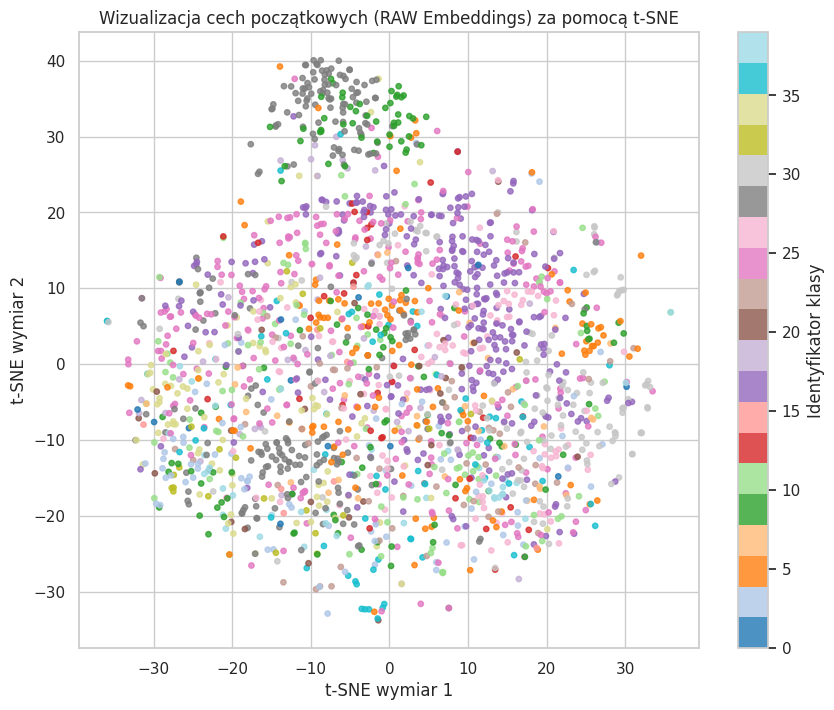

In [22]:
np.random.seed(42)
sample_indices = np.random.choice(data.num_nodes, size=2000, replace=False)

features_sample = data.x[sample_indices].numpy()
labels_sample = labels[sample_indices]

tsne = TSNE(n_components=2, random_state=42, n_iter=1000)
features_2d = tsne.fit_transform(features_sample)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_sample, cmap='tab20', s=15, alpha=0.8)
plt.colorbar(scatter, label="Identyfikator klasy")
plt.title("Wizualizacja cech początkowych (RAW Embeddings) za pomocą t-SNE")
plt.xlabel("t-SNE wymiar 1")
plt.ylabel("t-SNE wymiar 2")
plt.show()

### Interpretacja wyników EDA

Wyznaczone statystyki i wyrysowane wykresy pozwalają na zobrazowanie struktury grafu i potencjalnych trudności w późniejszym tworzeniu modeli:

- widać duży przeskok między liczbą wierzchołków (ok. 169 tys.) a liczbą krawędzi (ok. 1.1 mln); średni stopień wierzchołka pokazuje, że przeciętny artykuł jest połączony z kilkunastoma innymi, wykres logarytmiczny stopni ukazuje strukturę *scale-free* (kilka artykułów-hubów ma tysiące cytowań, większość ma tylko kilka)
- zidentyfikowano także brak zbalansowania klas - niektóre dziedziny mają znacznie więcej publikacji niż inne (dysproporcja 27321 vs 29); klasyfikatory mogą mieć tendencję do faworyzowania najczęstszych klas, co trzeba wziąć pod uwagę w dalszych etapach analizy
- współczynnik homofilii wynosi ok. 0.65 - oznacza to, że w 65% przypadków artykuł cytuje artykuł z tej samej dziedziny; struktura grafu niesie ogromną dawkę informacji, ale nie jest zbyt łatwa
- wykres t-SNE pokazuje jak wyglądają surowe wektory cech (pochodzące z tekstu) przed przetworzeniem przez graf; kropki o różnych kolorach (klasach) mocno się na siebie nakładają - oznacza to, że sam tekst artykułu nie wystarczy do idealnej klasyfikacji

Jasno pokazuje to, dlaczego tak trudno osiągnąć na tym zbiorze wyniki przekraczające 75% *accuracy*.


## Stworzenie i ewaluacja modeli bazowych

Jako baseline stworzono i wytrenowano modele:

- MLP (*multi-layer* perceptron, prosta sieć neuronowa),
- XGBoost,
- RandomForest.

Są to proste modele uczenia maszynowego i głębokiego ignorujące strukturę grafową, a bazujące tylko na cechach artykułów. Stanowią pole odniesienia dla późniejszych, bardziej zaawansowanych modeli grafowych.

### Pomocnicze struktury danych

Do przechowywania wyników metryk oceny skuteczności modeli i prawdopodobieństw przez nie zwróconych.

In [5]:
# dictionary that will contain performances of a given model
metrics = {}

# dictionary that will contain probabilities for a given model
probabilities = {}

### Pomocnicze funkcje

W większości zaczerpnięte z poprzedniego zadania (Zad01):

- funkcja obliczająca wartości metryk *accuracy*, *precision*, *recall*, *F1 score* i *ROC AUC* dla danego modelu
- funkcja rysująca macierz pomyłek (*confusion matrix*) dla przewidywań danego modelu
- funkcja rysująca krzywą ROC na podstawie prawdopodobieństw zwróconych przez dany model
- funkcja rysująca słupkowy wykres *accuracy* modelu w każdej klasie rozważanego zbioru danych
- funkcja rysująca wykres porównawczy ROC dla kilku modeli do niej przekazanej
- funkcja rysująca przebieg procesu nauki danego modelu

In [6]:
# function calculating metrics values for a given model

def calculate_metrics(model_name, y_pred, y_prob):
    probabilities[model_name] = y_prob
    metrics[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_test, y_pred, average='macro', zero_division=0),
        "f1": f1_score(y_test, y_pred, average='macro', zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob, multi_class='ovr'),
    }

In [7]:
# function creating confusion matrix for a given y_true and y_pred

def plot_confusion_matrix(y_pred):
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', include_values=False, ax=plt.gca())
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.xticks(fontsize=8, rotation=90)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

In [8]:
# function creating ROC curve plot for a given model

def plot_roc_curve(y_prob):
    n_classes = len(set(y_test))
    y_true_bin = label_binarize(y_test, classes=np.unique(y_test))

    plt.figure()

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)


        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multiclass)")
    plt.show()

In [9]:
# function calculating accuracy for each class

def accuracy_per_class(y_pred):
    cm = confusion_matrix(y_test, y_pred)
    acc_per_class = cm.diagonal() / cm.sum(axis=1)
    plt.bar(range(len(acc_per_class)), acc_per_class)
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per class")
    plt.show()

In [10]:
# function plotting ROC curves graph for list of models

def plot_compared_roc():
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10, 7))

    for name, y_score in probabilities.items():
        fpr = dict()
        tpr = dict()

        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

        mean_tpr /= n_classes

        macro_auc = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC = {macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Macro-averaged ROC curves")
    plt.legend()
    plt.grid()
    plt.show()

In [11]:
# function plotting loss and accuracy changes during learning process

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

### Przekształcenie danych z tensorów na wektory

In [12]:
X_train = data.x[split_idx['train']].cpu().numpy()
y_train = data.y[split_idx['train']].squeeze().cpu().numpy()

X_val = data.x[split_idx['valid']].cpu().numpy()
y_val = data.y[split_idx['valid']].squeeze().cpu().numpy()

X_test = data.x[split_idx['test']].cpu().numpy()
y_test = data.y[split_idx['test']].squeeze().cpu().numpy()

print(f"Rozmiar danych treningowych: {X_train.shape}")
print(f"Rozmiar danych testowych: {X_test.shape}")

Rozmiar danych treningowych: (90941, 128)
Rozmiar danych testowych: (48603, 128)


### RandomForest

In [16]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [27]:
y_pred = rf_model.predict(X_test)
y_pred_probs = rf_model.predict_proba(X_test)

calculate_metrics("RandomForest", y_pred, y_pred_probs)
metrics['RandomForest']

{'accuracy': 0.4385120260066251,
 'precision': 0.30174873408605507,
 'recall': 0.16623256849835566,
 'f1': 0.16139594360124498,
 'roc_auc': np.float64(0.8522458837739592)}

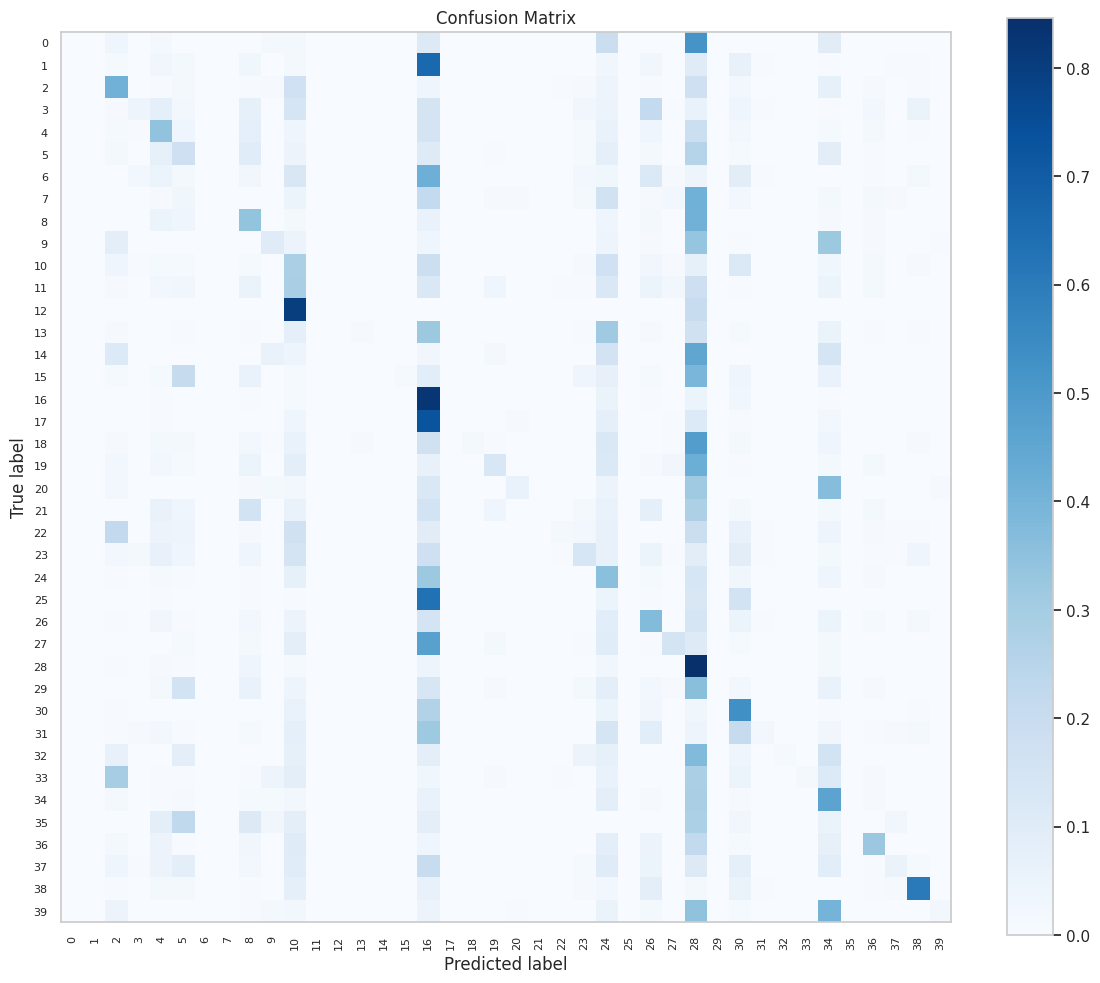

In [43]:
plot_confusion_matrix(y_pred)

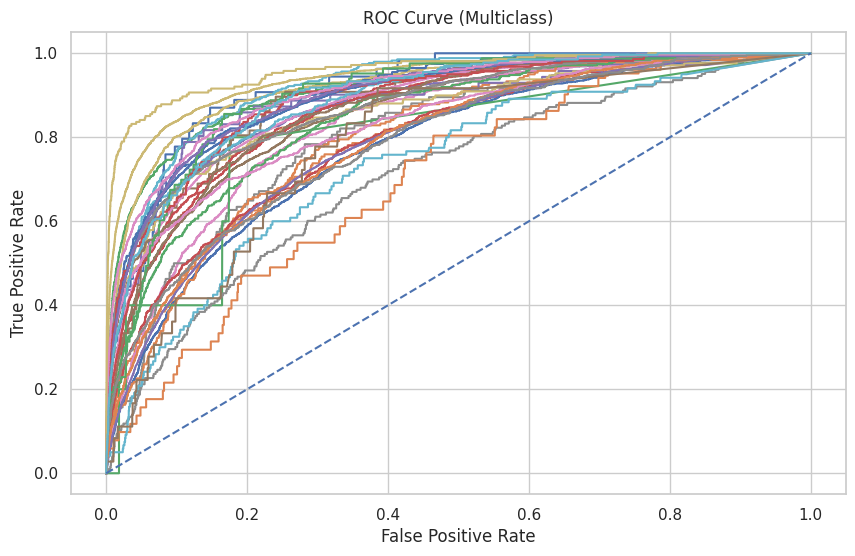

In [45]:
plot_roc_curve(y_pred_probs)

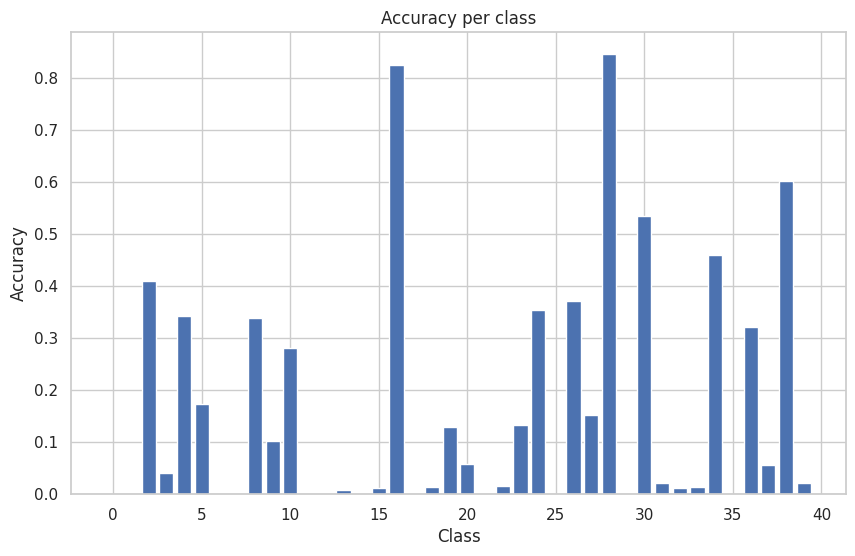

In [41]:
accuracy_per_class(y_pred)

Jak jasno widać z powyższych wykresów i wartości statystyk, prosty model RandomForest, oparty o drzewa decyzyjne, kompletnie nie poradził sobie z tak złożonym zbiorem. Całościowo osiągnął on skuteczność ok. 43%, jednak analiza skuteczności w poszczególnych klasach pokazuje, że było kilka klas (bardziej licznych) o wysokiej skuteczności, większość była na poziomie umiarkowanym, a pozostała część na znikomym lub zerowym. Krzywe ROC również pozostawiają wiele do życzenia. Pokazuje to, że proste modele będą miały tutaj duże trudności z osiągnięciem wysokiej skuteczności, ze względu na trudność danych i pominięcie struktury grafowej.

### XGBoost

In [26]:
xgb_device = "cuda" if torch.cuda.is_available() else "cpu"

xgb_model = xgb.XGBClassifier(
    n_estimators=60,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=40,
    tree_method="hist",
    device=xgb_device,
    random_state=42
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=10)

[0]	validation_0-mlogloss:2.87210
[10]	validation_0-mlogloss:2.26965
[20]	validation_0-mlogloss:2.02494
[30]	validation_0-mlogloss:1.88912
[40]	validation_0-mlogloss:1.80286
[50]	validation_0-mlogloss:1.74436
[59]	validation_0-mlogloss:1.70623


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=60,
              n_jobs=None, num_class=40, ...)

In [29]:
y_pred = xgb_model.predict(X_test)
y_pred_probs = xgb_model.predict_proba(X_test)

calculate_metrics("XGBoost", y_pred, y_pred_probs)
metrics['XGBoost']

{'accuracy': 0.48826204143777135,
 'precision': 0.34720362214686057,
 'recall': 0.2682034008527247,
 'f1': 0.2774010825300989,
 'roc_auc': np.float64(0.9144775087466599)}

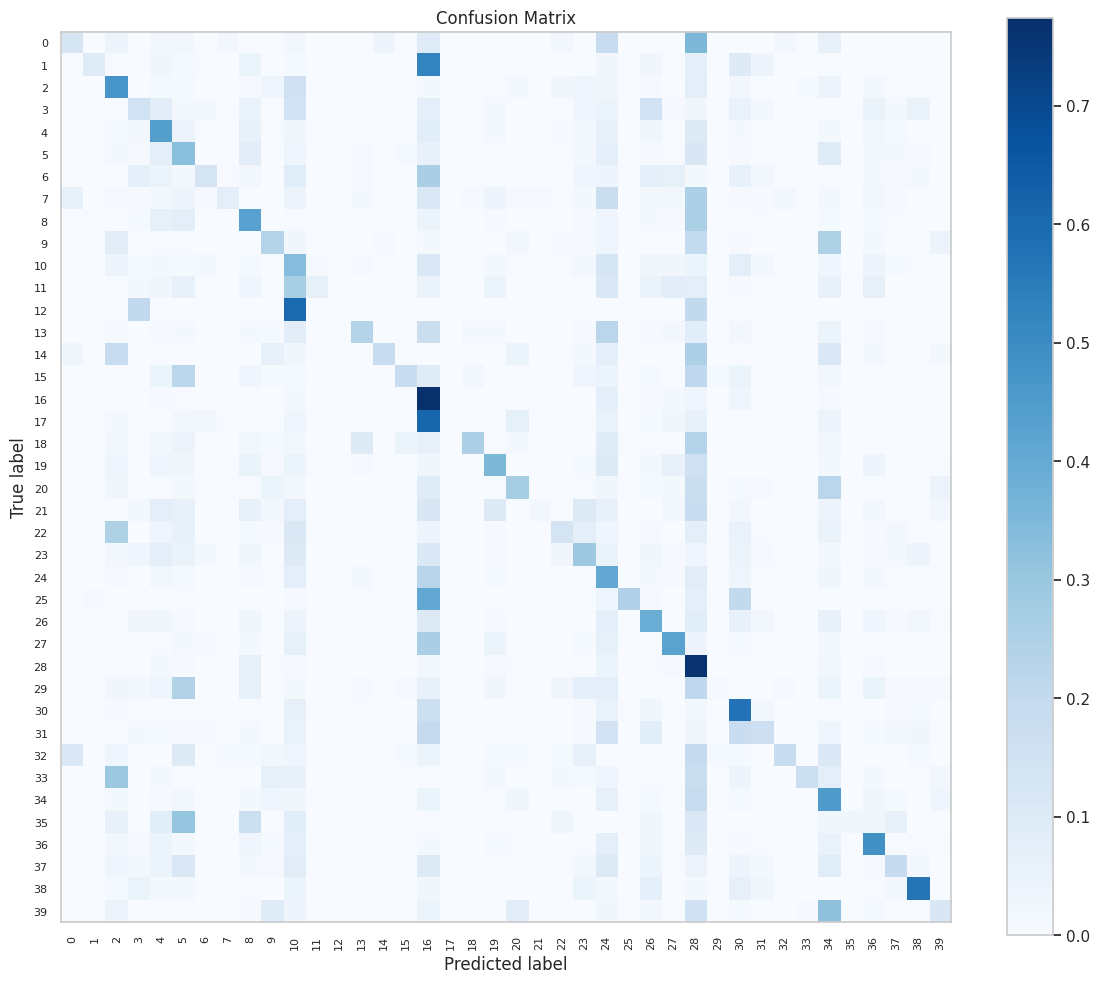

In [49]:
plot_confusion_matrix(y_pred)

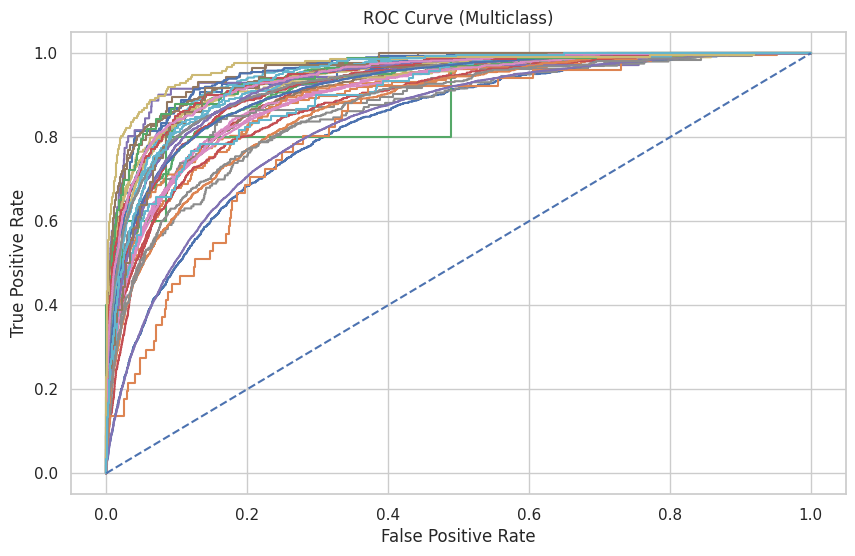

In [50]:
plot_roc_curve(y_pred_probs)

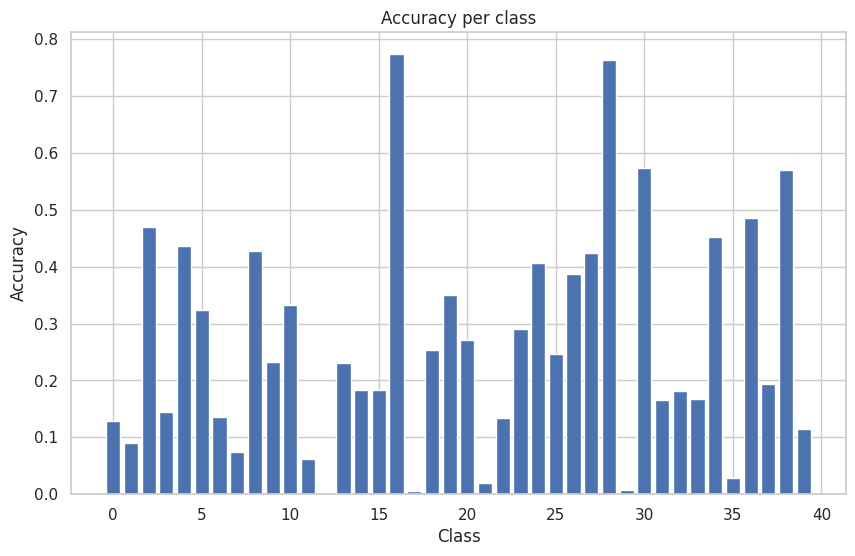

In [51]:
accuracy_per_class(y_pred)

Widać tu poprawę względem wcześniejszego modelu RandomForest. XGBoost zbliżył się do skuteczności 50%, widać też poprawę na macierzy pomyłek - zaczęła się wizualizować główna przekątna stanowiąca poprawne klasyfikacje. Widać też ogólny wzrost skuteczności w poszczególnych klasach. Nadal jednak są to wyniki dalekie od zadowalającego poziomu.

### MLP - Multi-Layer Perceptron

Stworzono architekturę składającą się z następujących warstw:

1. Liniowe wejście
2. Normalizacja wsadów 1D
3. Aktywacja ReLU
4. Dropout
5. Warstwa iniowa
6. Normalizacja wsadów 1D
7. Aktywacja ReLU
8. Dropout
9. Liniowe wyjście

W historii zapisywano *loss* i *accuracy* dla zbiorów treningowego i walidacyjnego.

Jako optymalizator wykorzystano `Adam` z krokiem uczenia 0.005. Jako kryterium przyjęto `CrossEntropyLoss`. Model trenowano przez 15 epok.

In [19]:
class PyTorchHistory:
    def __init__(self):
        self.history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

In [20]:
class TabularMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super(TabularMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

In [22]:
mlp_model = TabularMLP(in_dim=128, hidden_dim=256, out_dim=40).to(device)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.005, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history = PyTorchHistory()
EPOCHS = 15

In [23]:
for epoch in range(1, EPOCHS + 1):
    mlp_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_X.size(0)
        preds = outputs.argmax(dim=-1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
    train_loss = epoch_loss / total
    train_acc = correct / total
    
    mlp_model.eval()
    with torch.no_grad():
        val_inputs = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_targets = torch.tensor(y_val, dtype=torch.long).to(device)
        val_outputs = mlp_model(val_inputs)
        val_loss = criterion(val_outputs, val_targets).item()
        val_preds = val_outputs.argmax(dim=-1)
        val_acc = (val_preds == val_targets).float().mean().item()
        
    history.history['loss'].append(train_loss)
    history.history['accuracy'].append(train_acc)
    history.history['val_loss'].append(val_loss)
    history.history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch:02d} -> Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01 -> Train Loss: 1.7991 | Train Acc: 0.4883 | Val Acc: 0.5456
Epoch 02 -> Train Loss: 1.6435 | Train Acc: 0.5234 | Val Acc: 0.5519
Epoch 03 -> Train Loss: 1.6047 | Train Acc: 0.5327 | Val Acc: 0.5543
Epoch 04 -> Train Loss: 1.5755 | Train Acc: 0.5395 | Val Acc: 0.5658
Epoch 05 -> Train Loss: 1.5601 | Train Acc: 0.5414 | Val Acc: 0.5668
Epoch 06 -> Train Loss: 1.5481 | Train Acc: 0.5458 | Val Acc: 0.5607
Epoch 07 -> Train Loss: 1.5388 | Train Acc: 0.5476 | Val Acc: 0.5676
Epoch 08 -> Train Loss: 1.5286 | Train Acc: 0.5490 | Val Acc: 0.5695
Epoch 09 -> Train Loss: 1.5228 | Train Acc: 0.5522 | Val Acc: 0.5646
Epoch 10 -> Train Loss: 1.5156 | Train Acc: 0.5516 | Val Acc: 0.5667
Epoch 11 -> Train Loss: 1.5134 | Train Acc: 0.5546 | Val Acc: 0.5719
Epoch 12 -> Train Loss: 1.5037 | Train Acc: 0.5562 | Val Acc: 0.5607
Epoch 13 -> Train Loss: 1.5023 | Train Acc: 0.5570 | Val Acc: 0.5721
Epoch 14 -> Train Loss: 1.4973 | Train Acc: 0.5581 | Val Acc: 0.5672
Epoch 15 -> Train Loss: 1.4962 | T

In [30]:
mlp_model.eval()
with torch.no_grad():
    test_inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_outputs = mlp_model(test_inputs)
    y_prob = torch.softmax(test_outputs, dim=-1).cpu().numpy()
    y_pred = test_outputs.argmax(dim=-1).cpu().numpy()

calculate_metrics("MLP", y_pred, y_prob)
metrics["MLP"]

{'accuracy': 0.551879513610271,
 'precision': 0.3922553651800801,
 'recall': 0.331608661404427,
 'f1': 0.327334127538625,
 'roc_auc': np.float64(0.9374401525923226)}

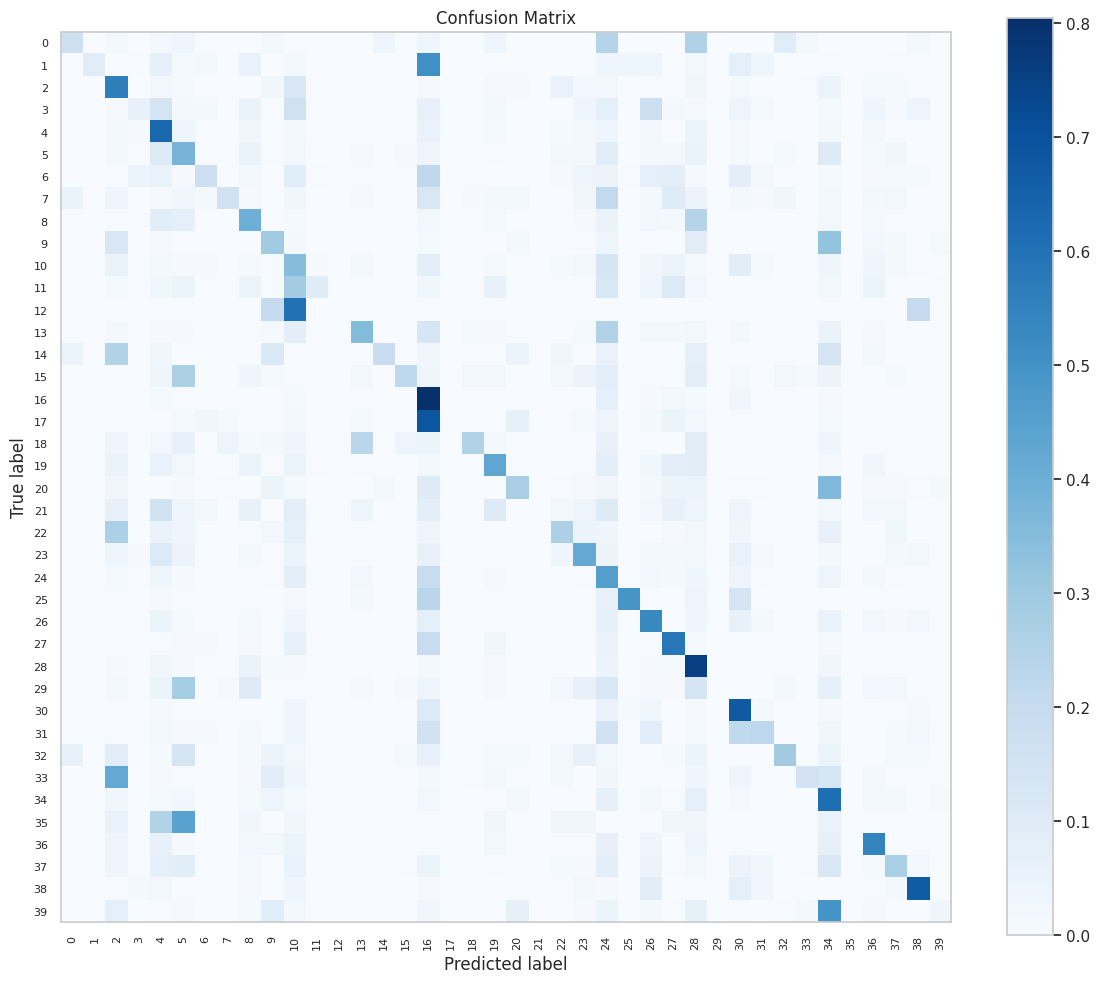

In [59]:
plot_confusion_matrix(y_pred)

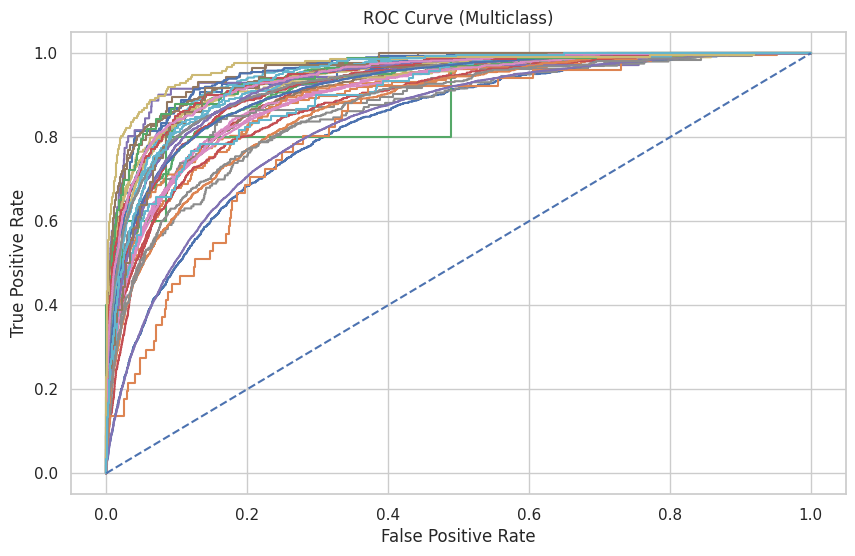

In [60]:
plot_roc_curve(y_pred_probs)

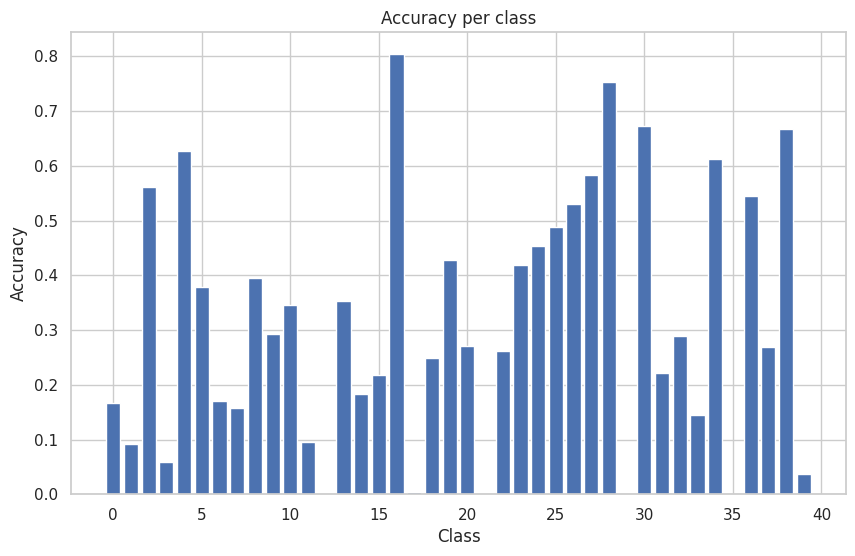

In [61]:
accuracy_per_class(y_pred)

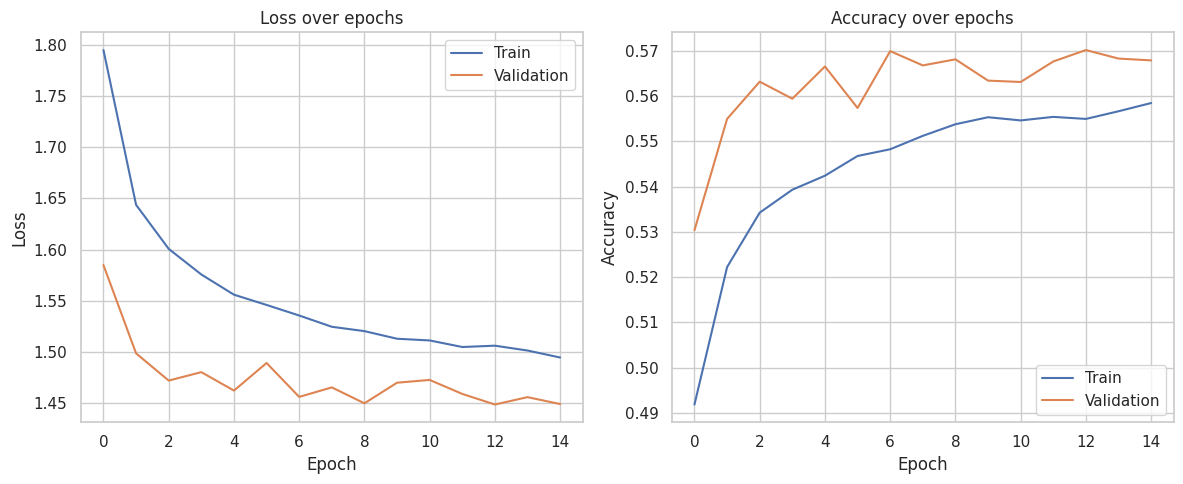

In [62]:
plot_training_history(history)

Model MLP stanowi kolejny krok w dobrą stronę. Osiągnięta ogólna skuteczność na poziomie 55% dla zbioru walidacyjnego i testowego to najwyższy do tej pory wynik. Widać wyraźnie zarysowaną główną przekątną macierzy pomyłek, również poszczególne wyniki *accuracy* w klasach są wyraźnie wyższe od modeli RandomForest i XGB. W dalszym ciągu jednak wyniki te nie są w żadnym stopniu zadowalające.

### Zestawienie modeli baseline

In [31]:
df = pd.DataFrame(metrics)
df.T

,accuracy,precision,recall,f1,roc_auc
RandomForest,0.438512,0.301749,0.166233,0.161396,0.852246
MLP,0.551880,0.392255,0.331609,0.327334,0.937440
XGBoost,0.488262,0.347204,0.268203,0.277401,0.914478


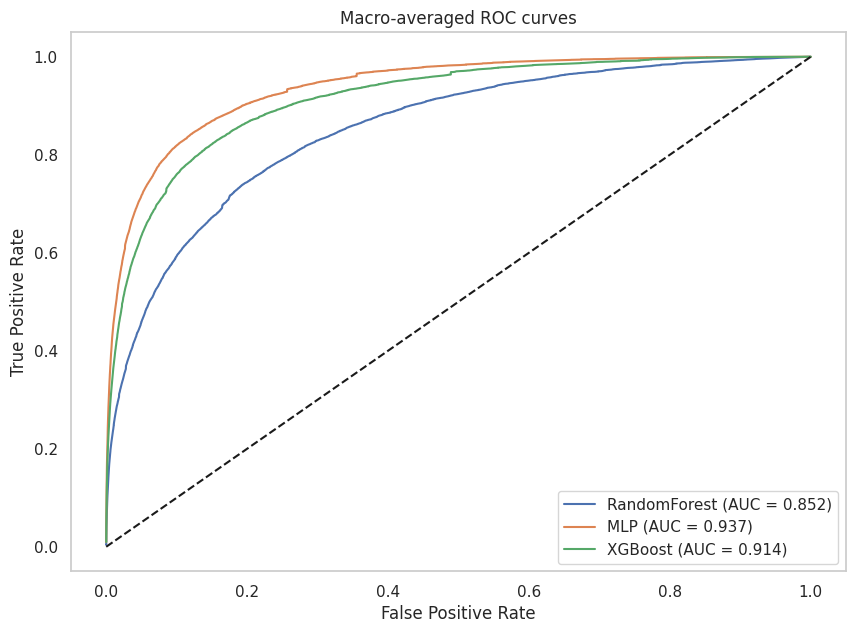

In [32]:
plot_compared_roc()

Z powyższych wartości statystyk i zbiorczego wykresu ROC AUC widać powolną, stopniową poprawę jaką przynosiło zastosowanie coraz lepszych modeli - najpierw RandomForest, później XGBoost, wreszcie Multi-Layer Perceptron. Najwyższy uzyskany wynik metryki *accuracy* to 55%. Widać więc, że żaden z powyższych modeli nie osiągnął zadowalających wyników. Pominięcie struktury grafowej danych (połączeń artykułów cytowaniami) stanowi poważne upośledzenie możliwości modeli uczenia maszynowego, z czym mają za zadanie poradzić sobie modele grafowe.

## Modele grafowe

### Uniwersalna funkcja treningu sieci grafowych

In [13]:
class PyTorchGNNHistory:
    def __init__(self):
        self.history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

In [14]:
def train_and_eval_gnn(model, name_str, epochs=100, lr=0.01):
    global data
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    model = model.to(device)
    
    gnn_history = PyTorchGNNHistory()
    
    train_idx = split_idx['train'].to(device)
    valid_idx = split_idx['valid'].to(device)
    test_idx = split_idx['test'].to(device)
    y_true_full = data.y.squeeze(1).to(device)
    
    
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index)
        
        loss = F.cross_entropy(out[train_idx], y_true_full[train_idx])
        loss.backward()
        optimizer.step()
        
        epoch_train_loss = loss.item()
        with torch.no_grad():
            train_preds = out[train_idx].argmax(dim=-1)
            epoch_train_acc = (train_preds == y_true_full[train_idx]).float().mean().item()
        
        model.eval()
        with torch.no_grad():
            full_out = model(data.x, data.edge_index)
            epoch_val_loss = F.cross_entropy(full_out[valid_idx], y_true_full[valid_idx]).item()
            val_preds = full_out[valid_idx].argmax(dim=-1)
            epoch_val_acc = (val_preds == y_true_full[valid_idx]).float().mean().item()
            
        gnn_history.history['loss'].append(epoch_train_loss)
        gnn_history.history['accuracy'].append(epoch_train_acc)
        gnn_history.history['val_loss'].append(epoch_val_loss)
        gnn_history.history['val_accuracy'].append(epoch_val_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch: {epoch:03d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    model.eval()
    with torch.no_grad():
        final_out = model(data.x, data.edge_index)
        test_out = final_out[test_idx]
        
        gnn_prob = F.softmax(test_out, dim=-1).cpu().numpy()
        gnn_pred = test_out.argmax(dim=-1).cpu().numpy()
    
    return gnn_pred, gnn_prob, gnn_history

In [17]:
probabilities = {}
metrics = {}

### GCN - Graph Convolutional Network

To grafowy odpowiednik rozmycia obrazu. Każdy węzeł aktualizuje swoją reprezentację, biorąc po prostu średnią z wektorów cech swoich sąsiadów oraz samego siebie. Przetwarzanie jest analogiczne do sieci konwolucyjnych. Kluczowe hiperparametry to `num_layers` i `hidden_channels`.

Stworzona sieć skałda się z 2 warstw `GCNConv`, funkcji aktywacji `ReLU` oraz odpowiedniego dropoutu.

In [53]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = 0.5

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [54]:
model_gcn = GCN(dataset.num_features, 128, dataset.num_classes)

In [55]:
y_pred, y_prob, history = train_and_eval_gnn(model_gcn, "GCN", epochs=100, lr=0.01)

Epoch: 001 | Train Loss: 3.7139 | Train Acc: 0.0234 || Val Loss: 3.4154 | Val Acc: 0.0765
Epoch: 005 | Train Loss: 3.0513 | Train Acc: 0.2432 || Val Loss: 2.8825 | Val Acc: 0.3018
Epoch: 010 | Train Loss: 2.7886 | Train Acc: 0.2788 || Val Loss: 2.7432 | Val Acc: 0.3014
Epoch: 015 | Train Loss: 2.5095 | Train Acc: 0.3577 || Val Loss: 2.4481 | Val Acc: 0.3809
Epoch: 020 | Train Loss: 2.2511 | Train Acc: 0.4294 || Val Loss: 2.1607 | Val Acc: 0.4709
Epoch: 025 | Train Loss: 2.0292 | Train Acc: 0.4732 || Val Loss: 1.9395 | Val Acc: 0.5081
Epoch: 030 | Train Loss: 1.8541 | Train Acc: 0.5055 || Val Loss: 1.7462 | Val Acc: 0.5465
Epoch: 035 | Train Loss: 1.7181 | Train Acc: 0.5378 || Val Loss: 1.6080 | Val Acc: 0.5827
Epoch: 040 | Train Loss: 1.6087 | Train Acc: 0.5614 || Val Loss: 1.4958 | Val Acc: 0.5984
Epoch: 045 | Train Loss: 1.5254 | Train Acc: 0.5765 || Val Loss: 1.4179 | Val Acc: 0.6144
Epoch: 050 | Train Loss: 1.4620 | Train Acc: 0.5898 || Val Loss: 1.3535 | Val Acc: 0.6218
Epoch: 055

In [56]:
calculate_metrics("GCN", y_pred, y_prob)
metrics["GCN"]

{'accuracy': 0.6586013209061169,
 'precision': 0.5129689866300515,
 'recall': 0.37166086708731516,
 'f1': 0.39256396909095315,
 'roc_auc': np.float64(0.9569074284571283)}

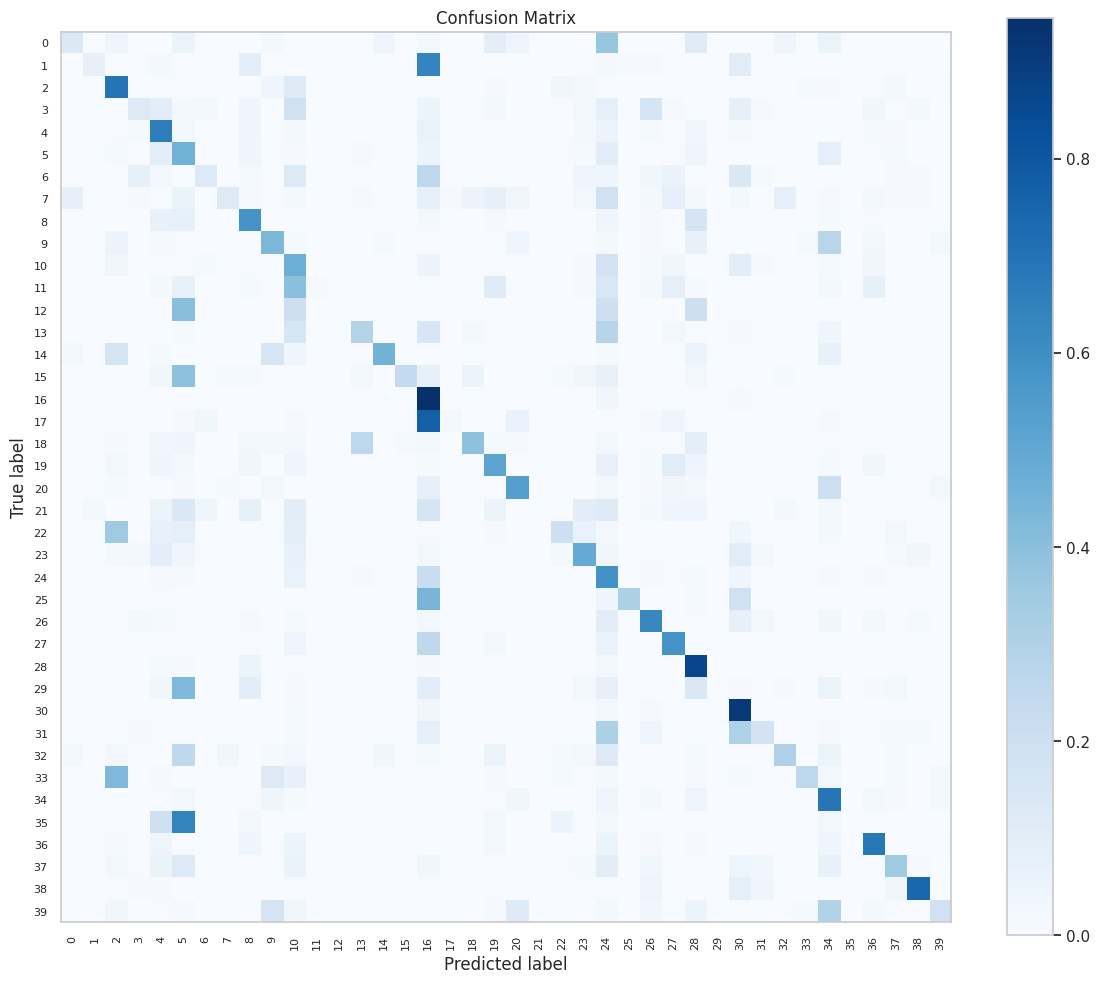

In [64]:
plot_confusion_matrix(y_pred)

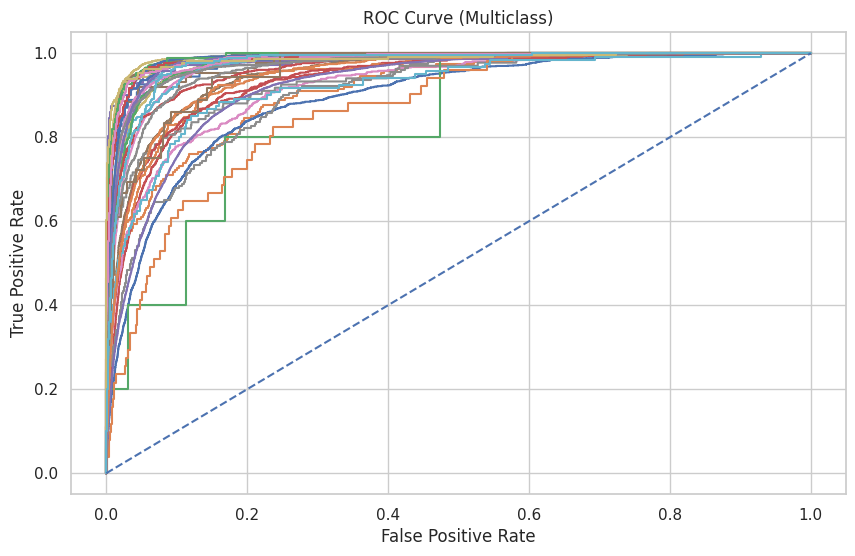

In [65]:
plot_roc_curve(y_prob)

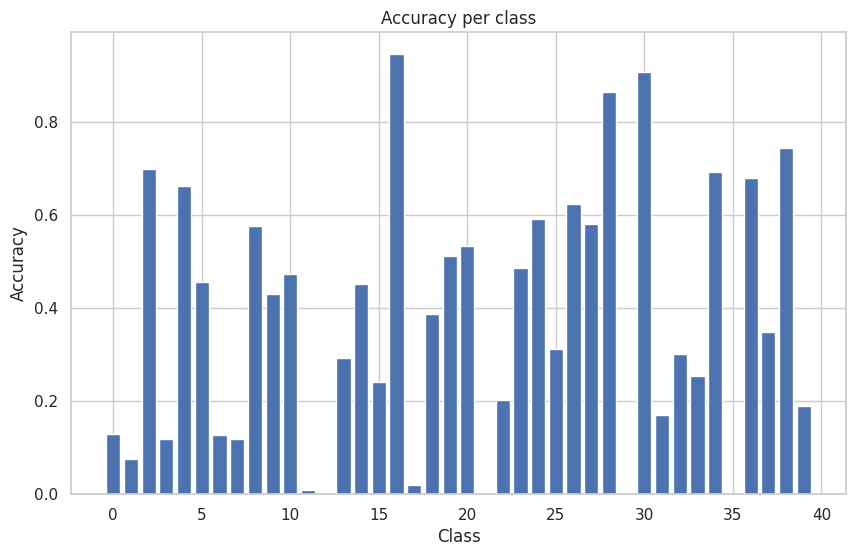

In [67]:
accuracy_per_class(y_pred)

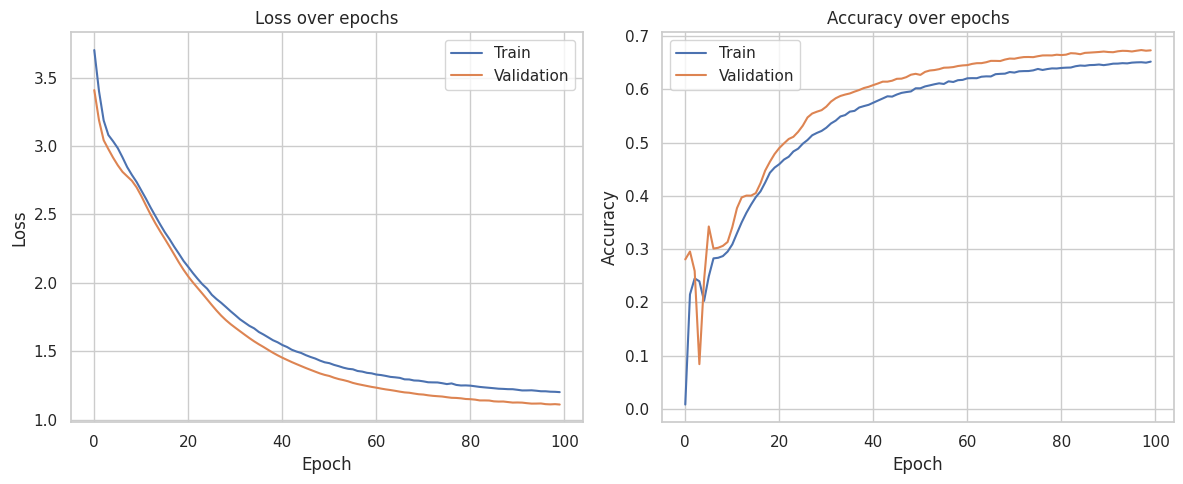

In [68]:
plot_training_history(history)

Już pierwszy, najprostszy model grafowy okazał się o niebo lepszy od klasycznych modeli baseline. Osiągnął ogólne *accuracy* rzędu 66% na zbiorze testowym, co daje wynik lepszy o ponad 10pp. od najlepszego dotąd modelu MLP. Widać również poprawę na macierzy pomyłek i krzywej ROC AUC. Sam proces nauki można uznać za bardzo stabilny i poprawny, nie wystąpił overfitting ani underfitting. Również skuteczność w obrębie poszczególnych klas wzrosła.

Pokazuje to znaczącą przewagę modeli grafowych i potęgę informacji o strukturze sieci.

### AdvancedGCN

Aby wycisnąć maksimum możliwości z modelu GCN zdecydowano się na wprowadzenie następujących ulepszeń:

- połączeń rezydualnych,
- normalizacji warstw,
- większej przestrzeni ukrytej (256 filtrów zamiast 128),
- większej liczby warstw (4 zamiast 2).

Sam proces nauki wydłużono do 150 epok.

In [57]:
class AdvancedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=4, dropout=0.3):
        super().__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.norms.append(LayerNorm(hidden_channels))
        
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.norms.append(LayerNorm(hidden_channels))
            
        self.convs.append(GCNConv(hidden_channels, out_channels))
        
        self.relu = ReLU()

    def forward(self, x, edge_index):
        for i in range(self.num_layers - 1):
            identity = x 
            
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = self.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
            if i > 0:
                x = x + identity
                
        x = self.convs[-1](x, edge_index)
        return x

In [58]:
model_adv_gcn = AdvancedGCN(
    in_channels=dataset.num_features, 
    hidden_channels=256, 
    out_channels=dataset.num_classes,
    num_layers=4,
    dropout=0.3
)

In [59]:
y_pred, y_prob, history = train_and_eval_gnn(
    model_adv_gcn, 
    "AdvancedGCN", 
    epochs=150,
    lr=0.005
)

Epoch: 001 | Train Loss: 4.8080 | Train Acc: 0.0314 || Val Loss: 5.4600 | Val Acc: 0.0763
Epoch: 005 | Train Loss: 6.3304 | Train Acc: 0.0487 || Val Loss: 5.3912 | Val Acc: 0.0346
Epoch: 010 | Train Loss: 3.2922 | Train Acc: 0.1750 || Val Loss: 3.1837 | Val Acc: 0.1541
Epoch: 015 | Train Loss: 3.3232 | Train Acc: 0.2914 || Val Loss: 2.9875 | Val Acc: 0.4195
Epoch: 020 | Train Loss: 2.9715 | Train Acc: 0.2624 || Val Loss: 2.9976 | Val Acc: 0.2923
Epoch: 025 | Train Loss: 2.7393 | Train Acc: 0.3183 || Val Loss: 2.6346 | Val Acc: 0.3653
Epoch: 030 | Train Loss: 2.5485 | Train Acc: 0.3705 || Val Loss: 2.5482 | Val Acc: 0.4445
Epoch: 035 | Train Loss: 2.3250 | Train Acc: 0.4161 || Val Loss: 2.2958 | Val Acc: 0.4929
Epoch: 040 | Train Loss: 2.1076 | Train Acc: 0.4751 || Val Loss: 2.0765 | Val Acc: 0.5250
Epoch: 045 | Train Loss: 1.8663 | Train Acc: 0.5132 || Val Loss: 1.8276 | Val Acc: 0.5676
Epoch: 050 | Train Loss: 1.6731 | Train Acc: 0.5605 || Val Loss: 1.6099 | Val Acc: 0.5980
Epoch: 055

In [60]:
calculate_metrics("AdvancedGCN", y_pred, y_prob)
metrics["AdvancedGCN"]

{'accuracy': 0.6957183712939531,
 'precision': 0.5510235003892162,
 'recall': 0.4911174943305786,
 'f1': 0.4983457340177801,
 'roc_auc': np.float64(0.9667968042885328)}

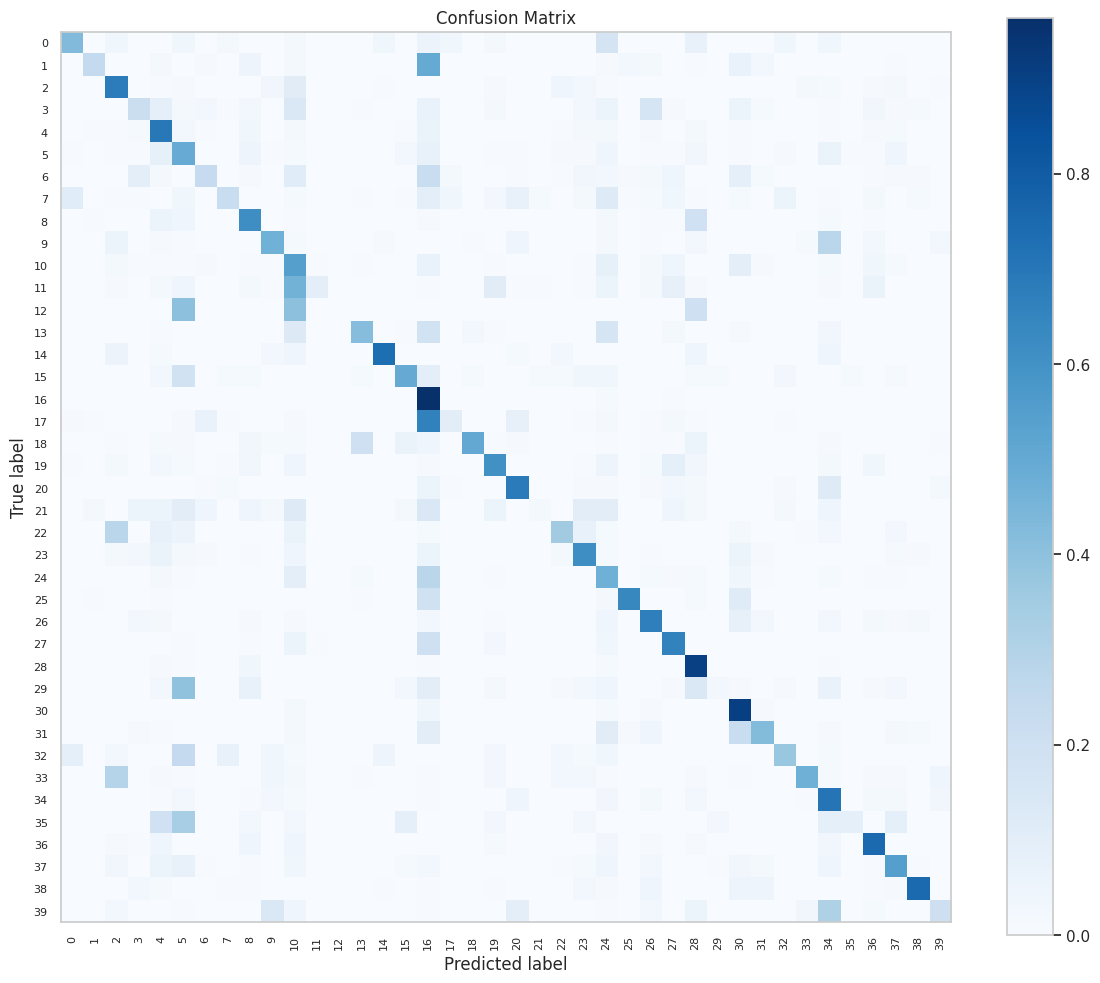

In [82]:
plot_confusion_matrix(y_pred)

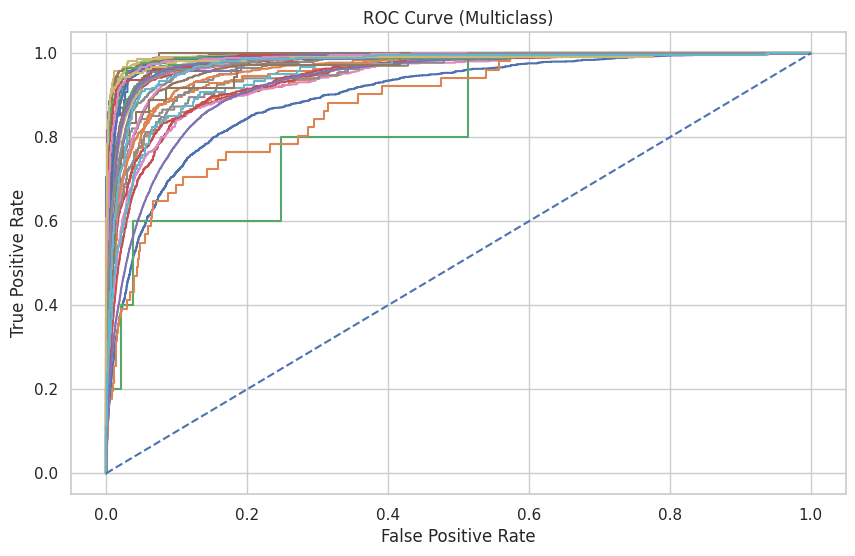

In [83]:
plot_roc_curve(y_prob)

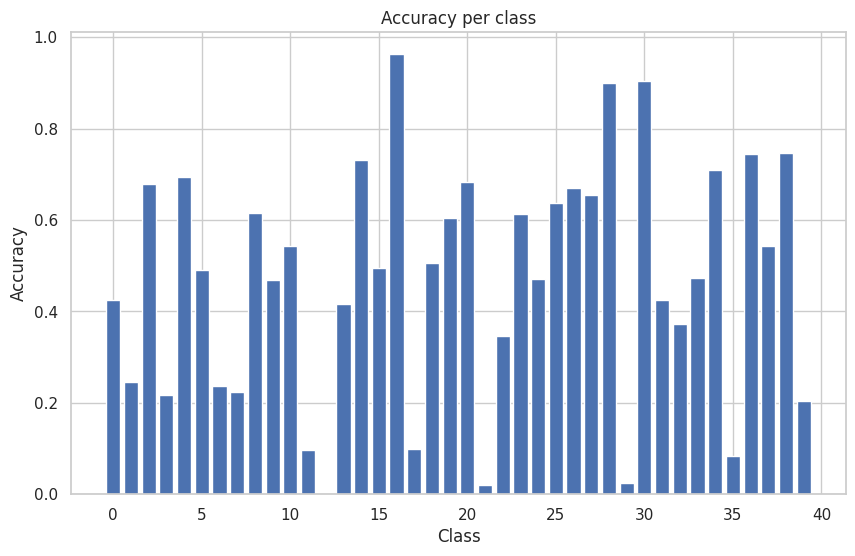

In [84]:
accuracy_per_class(y_pred)

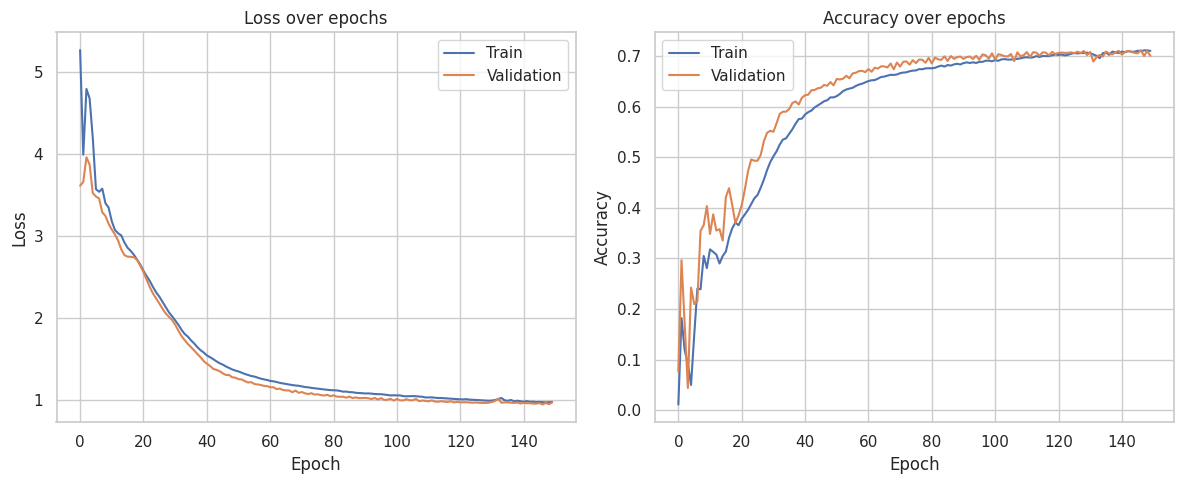

In [105]:
plot_training_history(history)

Widać, że rozbudowany model grafowo-konwolucyjny, pomimo początkowych fluktuacji, uzyskał bardzo dobre wyniki. *Accuracy* niemal osiągnęło 70% na zbiorze testowym, na zbiorach treningowym i walidacyjnym udało się tę granicę przekroczyć. Macierz pomyłek ma bardzo dobrze zarysowaną przekątną, również krzywe ROC AUC wykazują poprawę. Proces nauki był stabilny, mimo początkowych wahań.

Widać też, nie po raz pierwszy, trudności z dobrym rozpoznawaniem mniej licznie reprezentowanych klas. Pokazuje to wykres *accuracy per class*. Jest to trudne do wyeliminowania zjawisko, ze względu na grafową strukturę danych.

Uzyskane 70% *accuracy* można śmiało uznać za zadowalający wynik, zwłaszcza w świetle trudności wybranego zbioru danych. Jest on tylko nieznacznie (o ok. 7pp.) gorszy od topowych modeli.

### GraphSAGE (Sample and Aggregate)

Zamiast brać "sztywną" średnią z całego sąsiedztwa, GraphSAGE losowo próbkuje określoną liczbę sąsiadów, agreguje ich cechy (np. używając operacji MAX lub MEAN), a następnie konkatenuje wektor sąsiadów ze swoim własnym starym wektorem. To pozwala lepiej zachować tożsamość węzła źródłowego.

Kluczowe hiperparametry:

- `aggr`: Typ agregacji (`mean, max, lstm`).
- rozmiar próbkowania.

Stworzono architekturę opartą o 2 warstwy ukryte z funkcją aktywacji `ReLU`, wspierane odpowiednim dropoutem. Jako baseline przyjęto agregację średnią. Model trenowano przez 120 epok.

In [61]:
class SAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='mean')
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr='mean')
        self.dropout = 0.5

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [62]:
model_sage = SAGE(dataset.num_features, 128, dataset.num_classes)

In [63]:
y_pred, y_prob, history = train_and_eval_gnn(model_sage, "GraphSAGE", epochs=120, lr=0.01)

Epoch: 001 | Train Loss: 3.6436 | Train Acc: 0.0414 || Val Loss: 3.1636 | Val Acc: 0.0763
Epoch: 005 | Train Loss: 2.9273 | Train Acc: 0.2402 || Val Loss: 2.8259 | Val Acc: 0.2910
Epoch: 010 | Train Loss: 2.5083 | Train Acc: 0.3172 || Val Loss: 2.3073 | Val Acc: 0.3573
Epoch: 015 | Train Loss: 2.1316 | Train Acc: 0.4085 || Val Loss: 1.9276 | Val Acc: 0.4496
Epoch: 020 | Train Loss: 1.8976 | Train Acc: 0.4654 || Val Loss: 1.6862 | Val Acc: 0.5223
Epoch: 025 | Train Loss: 1.7284 | Train Acc: 0.5125 || Val Loss: 1.5419 | Val Acc: 0.5650
Epoch: 030 | Train Loss: 1.6083 | Train Acc: 0.5464 || Val Loss: 1.4362 | Val Acc: 0.5887
Epoch: 035 | Train Loss: 1.5160 | Train Acc: 0.5667 || Val Loss: 1.3512 | Val Acc: 0.6049
Epoch: 040 | Train Loss: 1.4471 | Train Acc: 0.5834 || Val Loss: 1.2881 | Val Acc: 0.6197
Epoch: 045 | Train Loss: 1.4002 | Train Acc: 0.5978 || Val Loss: 1.2418 | Val Acc: 0.6287
Epoch: 050 | Train Loss: 1.3565 | Train Acc: 0.6068 || Val Loss: 1.2062 | Val Acc: 0.6373
Epoch: 055

In [64]:
calculate_metrics("SAGE", y_pred, y_prob)
metrics["SAGE"]

{'accuracy': 0.6717075077670103,
 'precision': 0.5111754170457111,
 'recall': 0.4062352299774806,
 'f1': 0.42550788259806077,
 'roc_auc': np.float64(0.9599512158834246)}

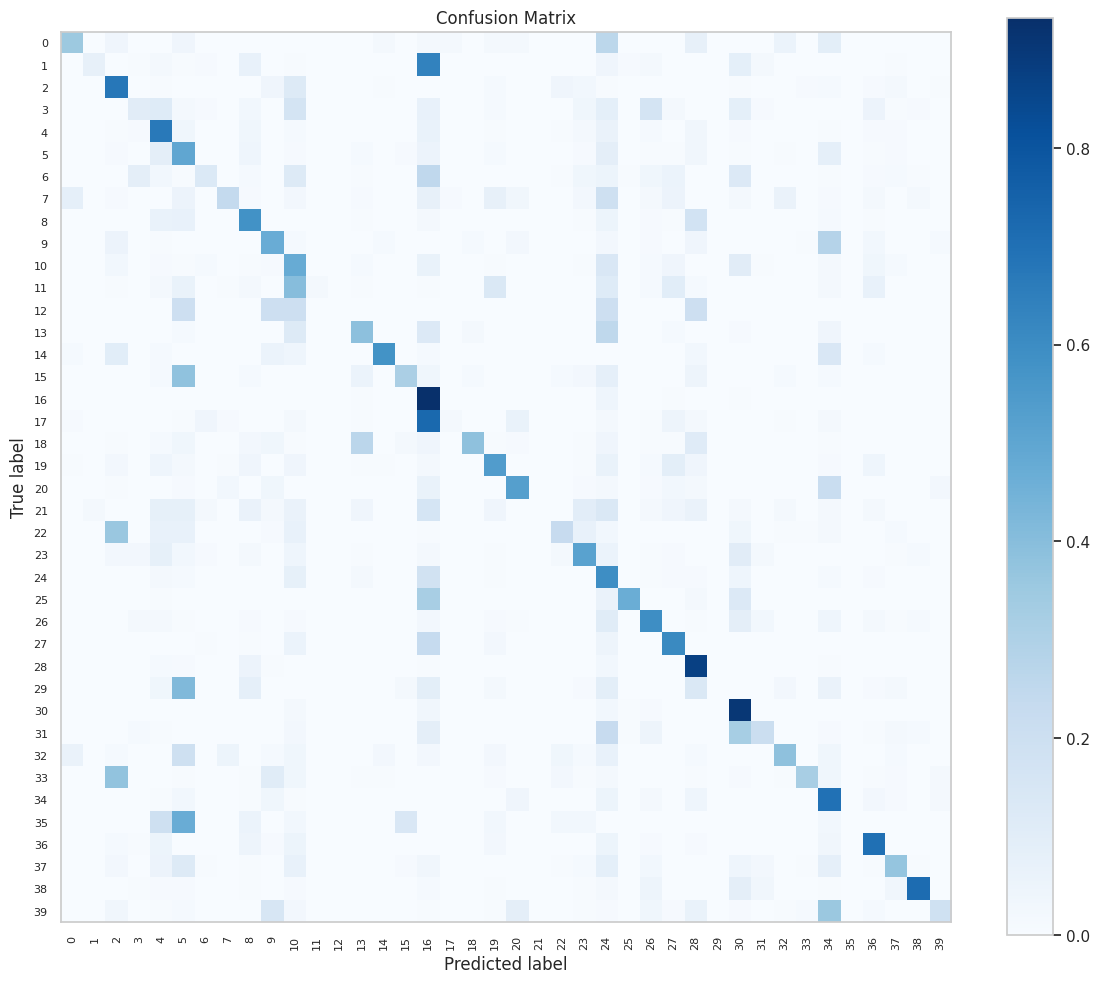

In [99]:
plot_confusion_matrix(y_pred)

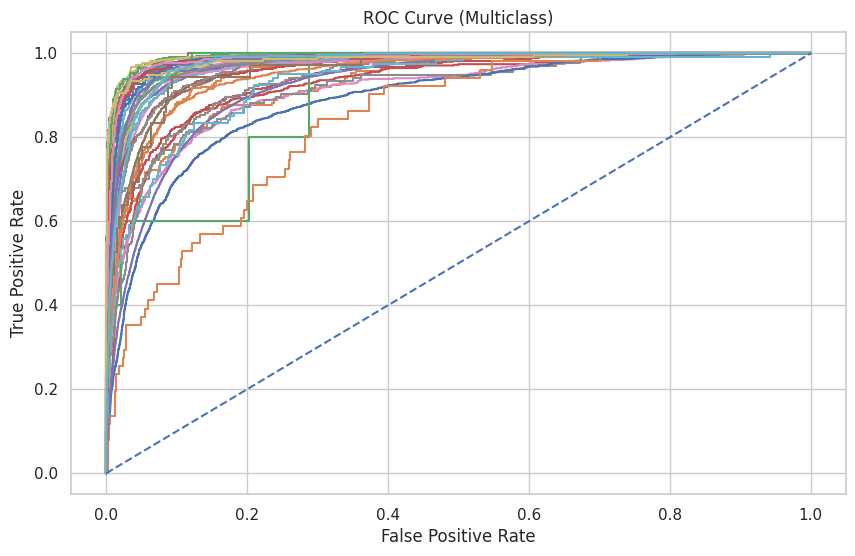

In [100]:
plot_roc_curve(y_prob)

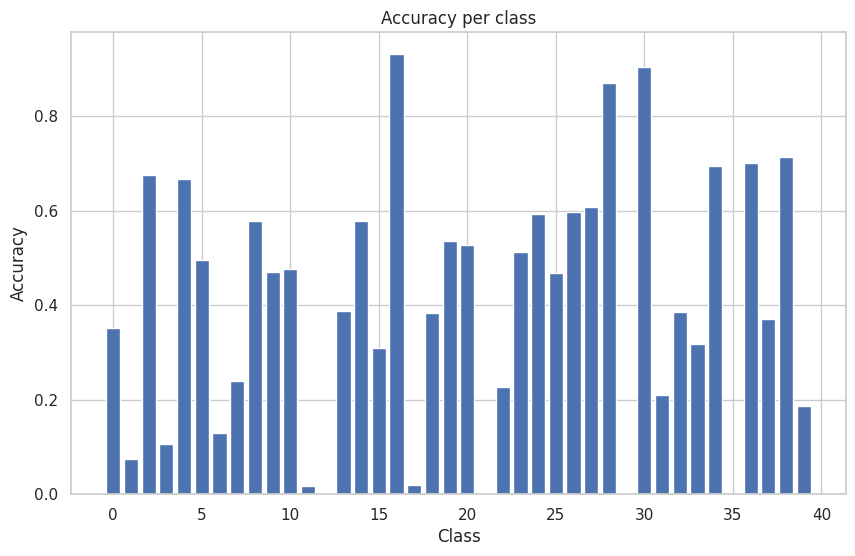

In [101]:
accuracy_per_class(y_pred)

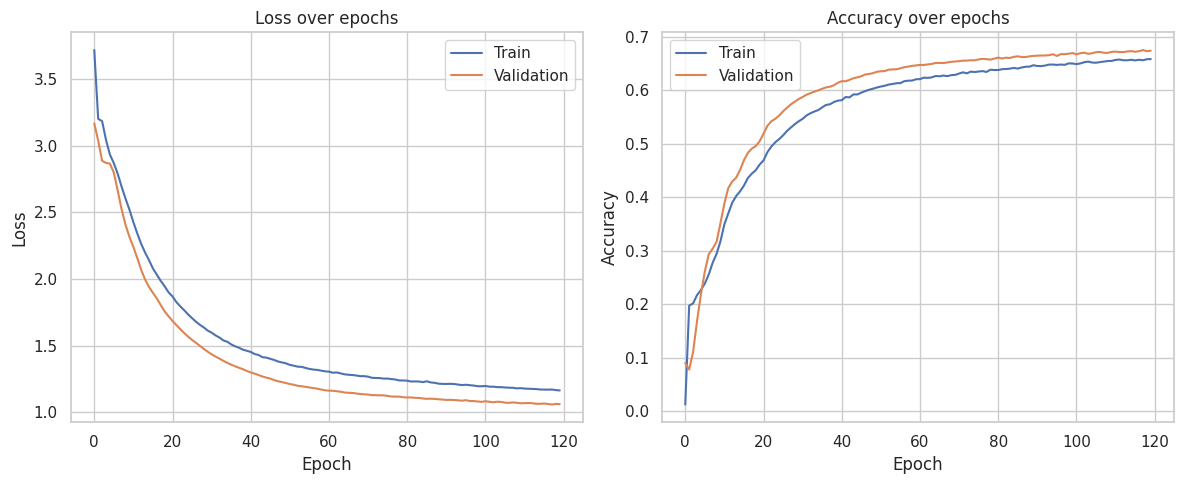

In [111]:
plot_training_history(history)

Model SAGE osiągnął wyniki bardzo zbliżone do wcześniejszego modelu GCN. *Accuracy* rzędu 70% można więc przyjąć jako baseline benchmark dla kolejnych modeli. Dobrze wygląda macierz konfuzji, krzywe historii nauki wskazują, że proces ten był stabilny i obyło sie bez niekorzystnych zjawisk. W dalszym ciągu kuleją mało reprezentowane klasy, jednak w ogólności model można uznać za bardzo dobry, zwłaszcza wobec wysokiej trudności wybranego zbioru danych.

### AdvancedGraphSAGE

Aby uzyskać jeszcze lepsze wyniki, model SAGE został rozbudowany:

- zmieniono sposób agregacji na `max`,
- dodano połączenia rezydualne,
- wprowadzono normalizację wsadów,
- zastosowano *jumping knowledge*.

Model zbudowano z 3 warstw po 256 cech, zwiększono także poziom dropoutu. Model trenowano przez 120 epok.

In [65]:
class AdvancedSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.3):
        super().__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        
        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr='max'))
        self.norms.append(LayerNorm(hidden_channels))
        
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr='max'))
            self.norms.append(LayerNorm(hidden_channels))
            
        self.lin_out = Linear(hidden_channels * num_layers, out_channels)
        self.relu = ReLU()

    def forward(self, x, edge_index):
        layer_outputs = []
        
        for i in range(self.num_layers):
            identity = x
            
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = self.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
            if i > 0:
                x = x + identity
                
            layer_outputs.append(x)
            
        x = torch.cat(layer_outputs, dim=-1)
        x = self.lin_out(x)
        return x

In [69]:
model_adv_sage = AdvancedSAGE(
    in_channels=dataset.num_features,
    hidden_channels=128,
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.4
)

In [70]:
y_pred, y_prob, history = train_and_eval_gnn(
    model_adv_sage, 
    "AdvancedSAGE",
    epochs=120, 
    lr=0.01
)

Epoch: 001 | Train Loss: 4.0230 | Train Acc: 0.0293 || Val Loss: 4.3349 | Val Acc: 0.0763
Epoch: 005 | Train Loss: 3.8816 | Train Acc: 0.0544 || Val Loss: 3.7171 | Val Acc: 0.0413
Epoch: 010 | Train Loss: 3.4552 | Train Acc: 0.2007 || Val Loss: 2.9140 | Val Acc: 0.2654
Epoch: 015 | Train Loss: 3.0336 | Train Acc: 0.2014 || Val Loss: 2.9109 | Val Acc: 0.1607
Epoch: 020 | Train Loss: 2.8529 | Train Acc: 0.2574 || Val Loss: 2.5869 | Val Acc: 0.2855
Epoch: 025 | Train Loss: 2.6262 | Train Acc: 0.2988 || Val Loss: 2.3986 | Val Acc: 0.3425
Epoch: 030 | Train Loss: 2.3928 | Train Acc: 0.3165 || Val Loss: 2.1643 | Val Acc: 0.3391
Epoch: 035 | Train Loss: 2.1565 | Train Acc: 0.3888 || Val Loss: 1.9457 | Val Acc: 0.4484
Epoch: 040 | Train Loss: 1.9929 | Train Acc: 0.4256 || Val Loss: 1.8115 | Val Acc: 0.4775
Epoch: 045 | Train Loss: 1.8595 | Train Acc: 0.4642 || Val Loss: 1.6546 | Val Acc: 0.5189
Epoch: 050 | Train Loss: 1.7378 | Train Acc: 0.4994 || Val Loss: 1.5341 | Val Acc: 0.5556
Epoch: 055

In [71]:
calculate_metrics("AdvancedSAGE", y_pred, y_prob)
metrics["AdvancedSAGE"]

{'accuracy': 0.6842993230870522,
 'precision': 0.5056922393343657,
 'recall': 0.42620163490445373,
 'f1': 0.4380390171079144,
 'roc_auc': np.float64(0.9687236419685237)}

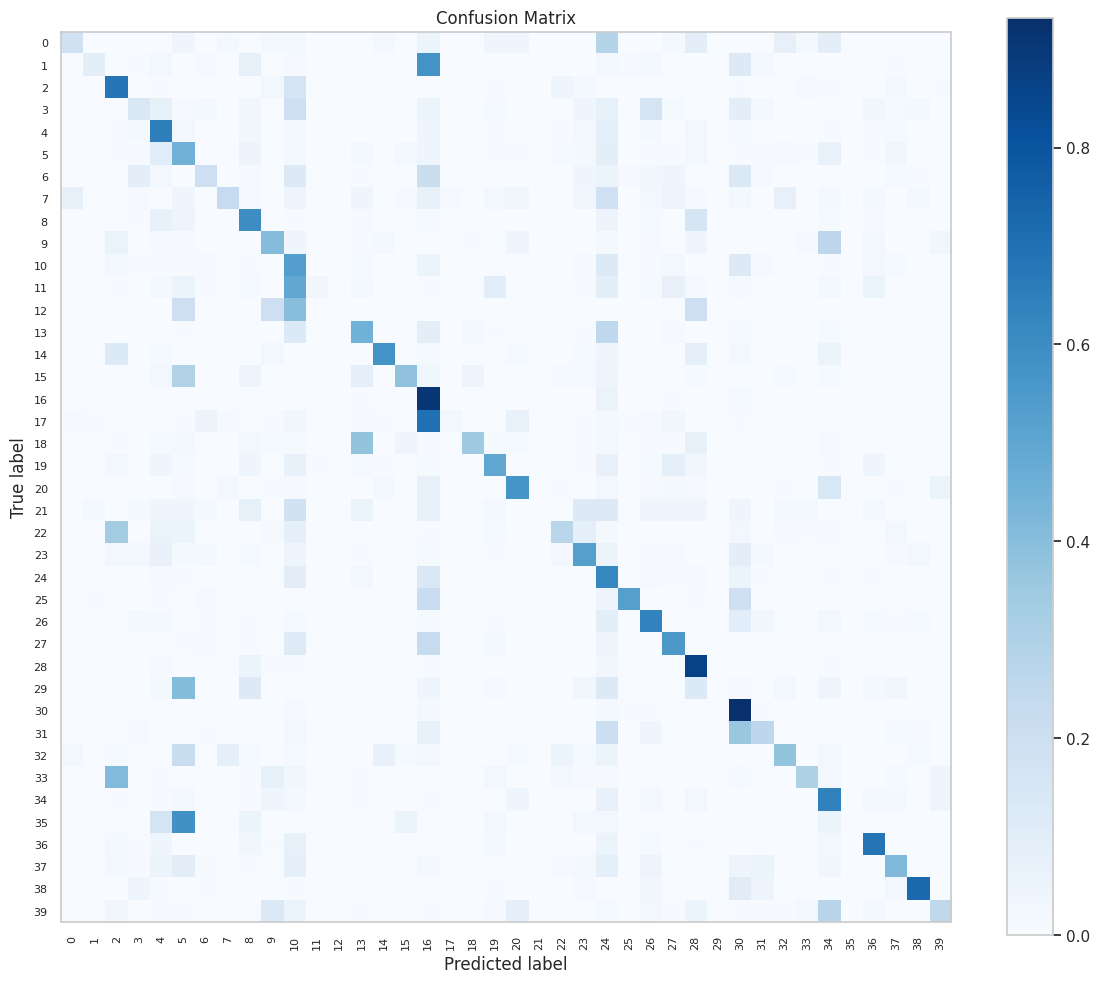

In [44]:
plot_confusion_matrix(y_pred)

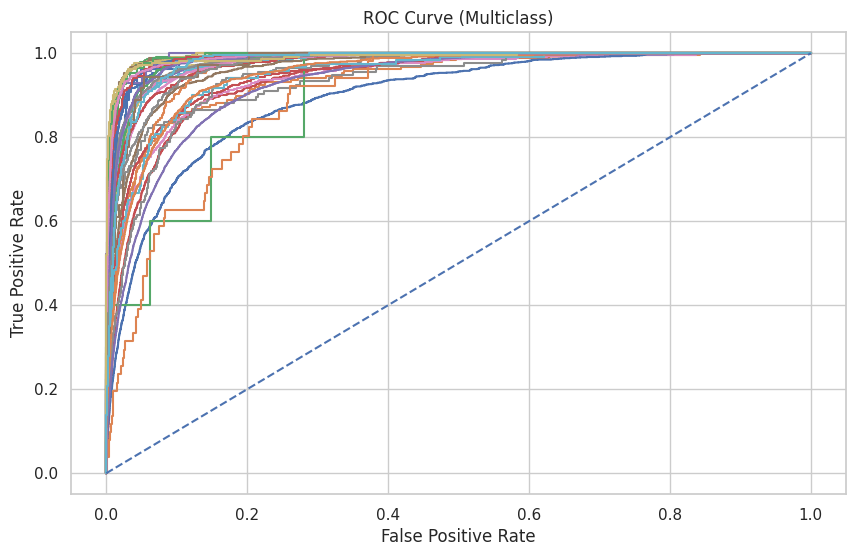

In [45]:
plot_roc_curve(y_prob)

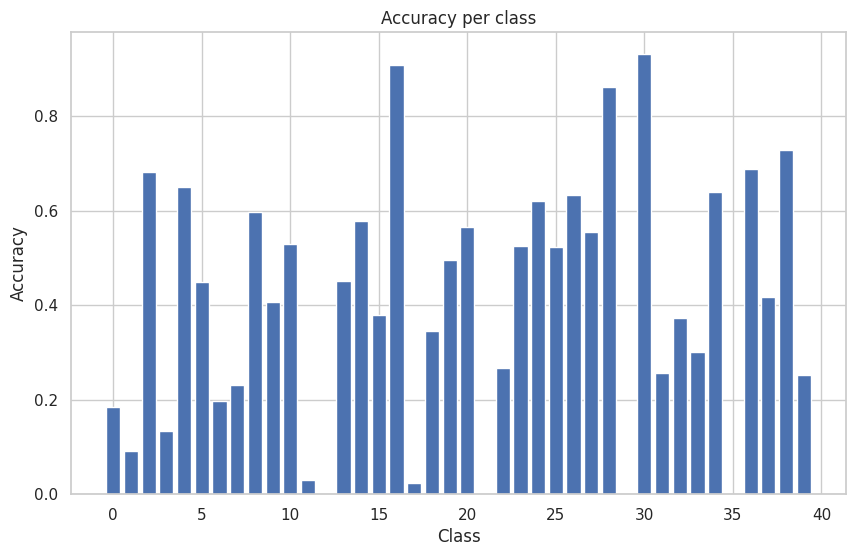

In [46]:
accuracy_per_class(y_pred)

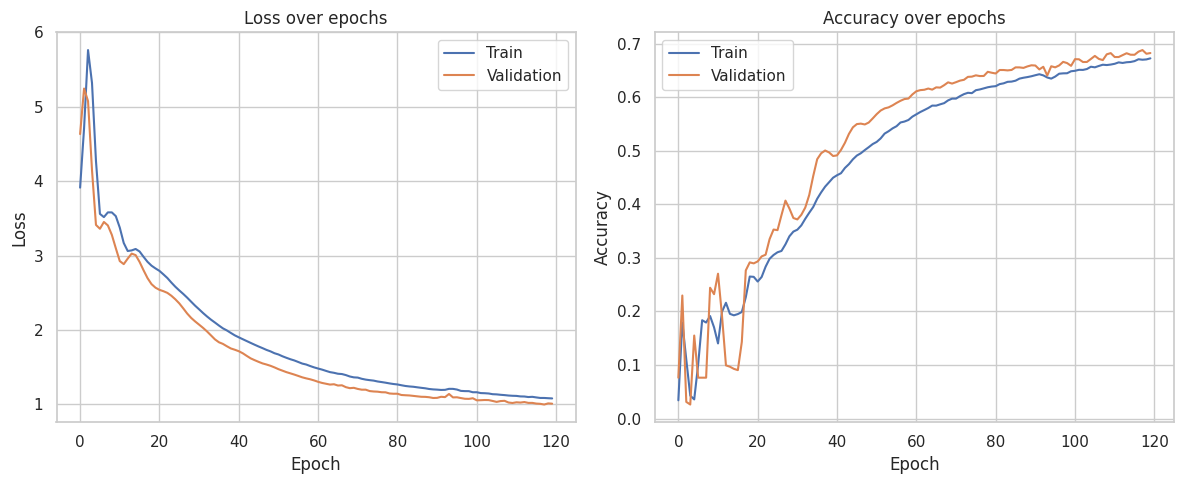

In [47]:
plot_training_history(history)

Widać większe niż do tej pory wahania podczas procesu nauki, widoczne na powyższym wykresie. Ogólne wyniki modelu można uznać za poprawne, brak tu jednak oczekiwanego polepszenia względem jego prostszej wersji. Niemniej jest to kolejny model osiągający *accuracy* bliskie 70%, które jest bardzo zadowalającym wynikiem na tym zbiorze.

### GAT - Graph Attention 

GAT odrzuca ideę "każdy sąsiad jest tak samo ważny". Wprowadza system uwagi (Attention) przypominający ten z modeli językowych (Transformer). Sieć sama uczy się wagi dla każdej krawędzi – potrafi zignorować mało ważny artykuł, a skupić 90% uwagi na jednym, kluczowym dokumencie cytowanym przez dany wierzchołek.

Najważniejsze hiperparametry:

- `heads`: liczba głów uwagi, pozwala to sieci analizować sąsiedztwo z kilku różnych perspektyw naraz
- `dropout` w uwadze zapobiegający uczeniu się "na pamięć".

Zbudowano strukturę w oparciu o 2 warstwy `GATConv`, zastosowano dropout i funcję aktywacji `ELu`. Model trenowany był przez 100 epok.

In [72]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_channels, 64, heads=heads, dropout=0.3)
        self.conv2 = GATConv(64 * heads, out_channels, heads=1, concat=False, dropout=0.3)
        self.dropout = 0.5

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [73]:
model_gat = GAT(dataset.num_features, hidden_channels=64, out_channels=dataset.num_classes)

In [74]:
y_pred, y_prob, history = train_and_eval_gnn(model_gat, "GAT", epochs=100, lr=0.005)

Epoch: 001 | Train Loss: 3.6888 | Train Acc: 0.0344 || Val Loss: 3.3061 | Val Acc: 0.0763
Epoch: 005 | Train Loss: 2.9814 | Train Acc: 0.2690 || Val Loss: 2.7470 | Val Acc: 0.3200
Epoch: 010 | Train Loss: 2.6948 | Train Acc: 0.2893 || Val Loss: 2.4987 | Val Acc: 0.3094
Epoch: 015 | Train Loss: 2.4070 | Train Acc: 0.3840 || Val Loss: 2.1993 | Val Acc: 0.4421
Epoch: 020 | Train Loss: 2.1658 | Train Acc: 0.4492 || Val Loss: 1.9205 | Val Acc: 0.4979
Epoch: 025 | Train Loss: 1.9775 | Train Acc: 0.4948 || Val Loss: 1.7345 | Val Acc: 0.5598
Epoch: 030 | Train Loss: 1.8594 | Train Acc: 0.5159 || Val Loss: 1.5796 | Val Acc: 0.5904
Epoch: 035 | Train Loss: 1.7639 | Train Acc: 0.5337 || Val Loss: 1.4883 | Val Acc: 0.5955
Epoch: 040 | Train Loss: 1.6882 | Train Acc: 0.5533 || Val Loss: 1.4095 | Val Acc: 0.6166
Epoch: 045 | Train Loss: 1.6301 | Train Acc: 0.5633 || Val Loss: 1.3525 | Val Acc: 0.6232
Epoch: 050 | Train Loss: 1.5902 | Train Acc: 0.5729 || Val Loss: 1.3044 | Val Acc: 0.6309
Epoch: 055

In [75]:
calculate_metrics("GAT", y_pred, y_prob)
metrics["GAT"]

{'accuracy': 0.6571199308684649,
 'precision': 0.4754500328726861,
 'recall': 0.35148532235195723,
 'f1': 0.37059550575115296,
 'roc_auc': np.float64(0.9559520287114298)}

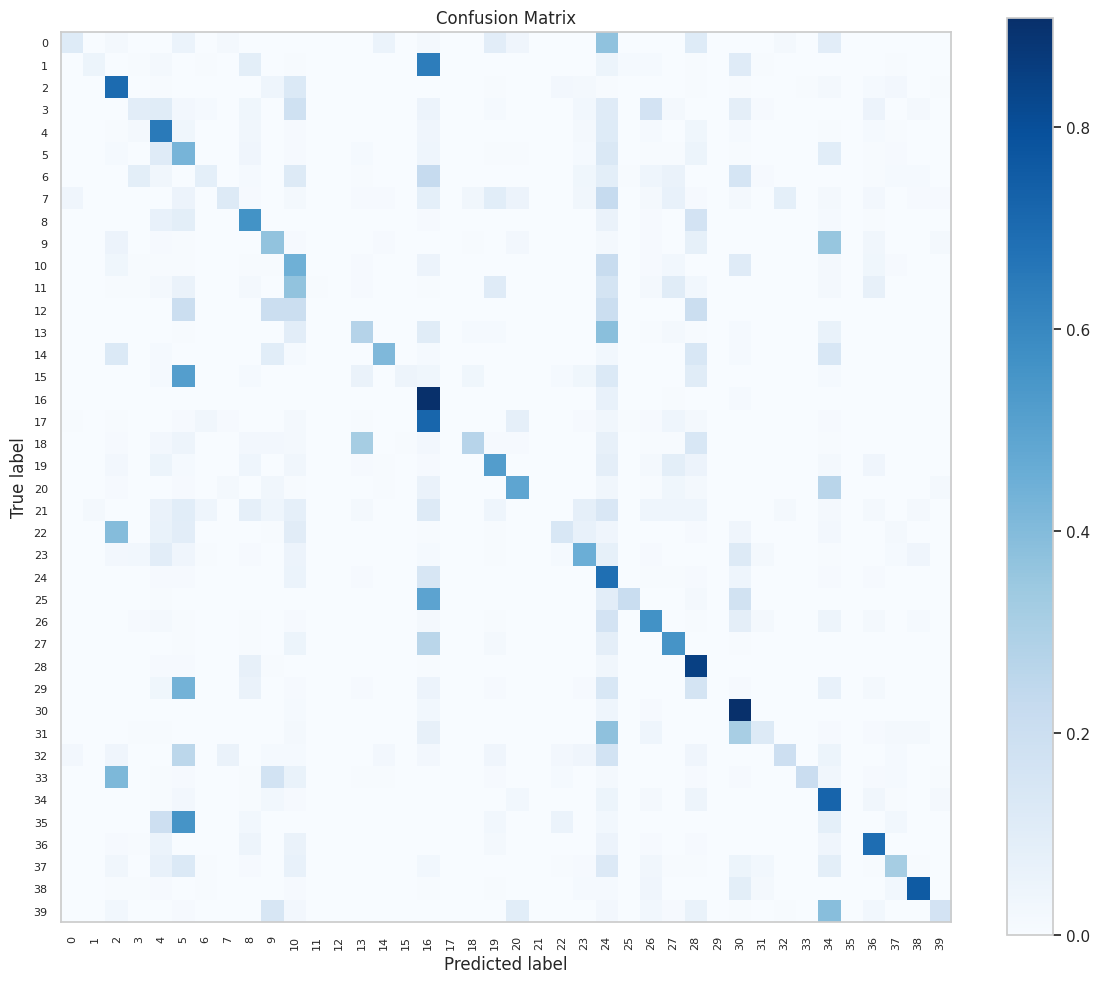

In [22]:
plot_confusion_matrix(y_pred)

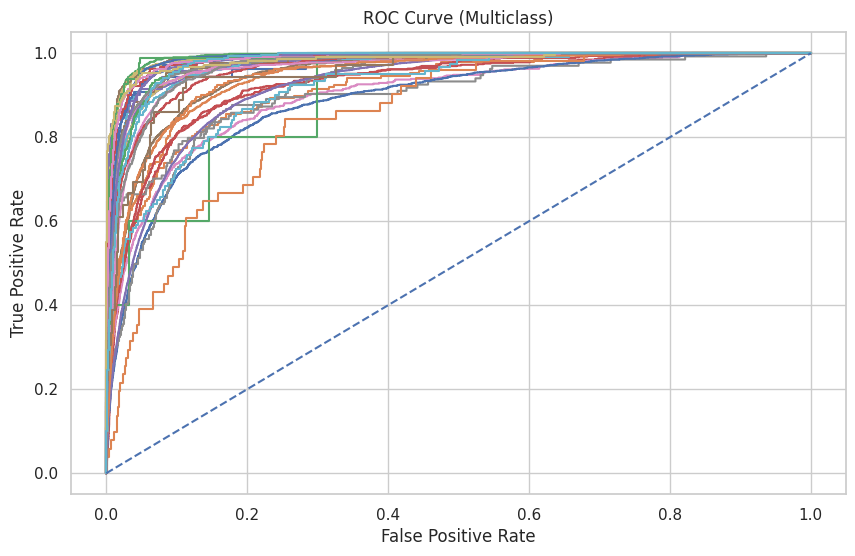

In [23]:
plot_roc_curve(y_prob)

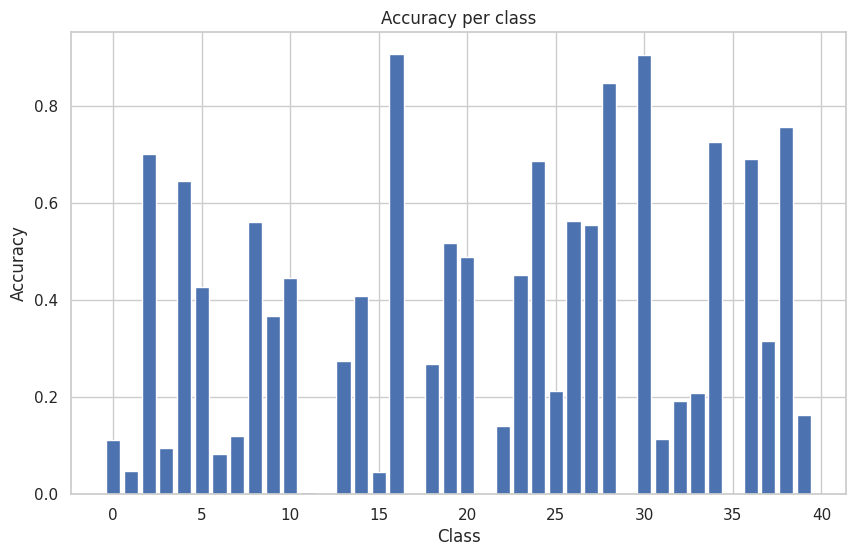

In [24]:
accuracy_per_class(y_pred)

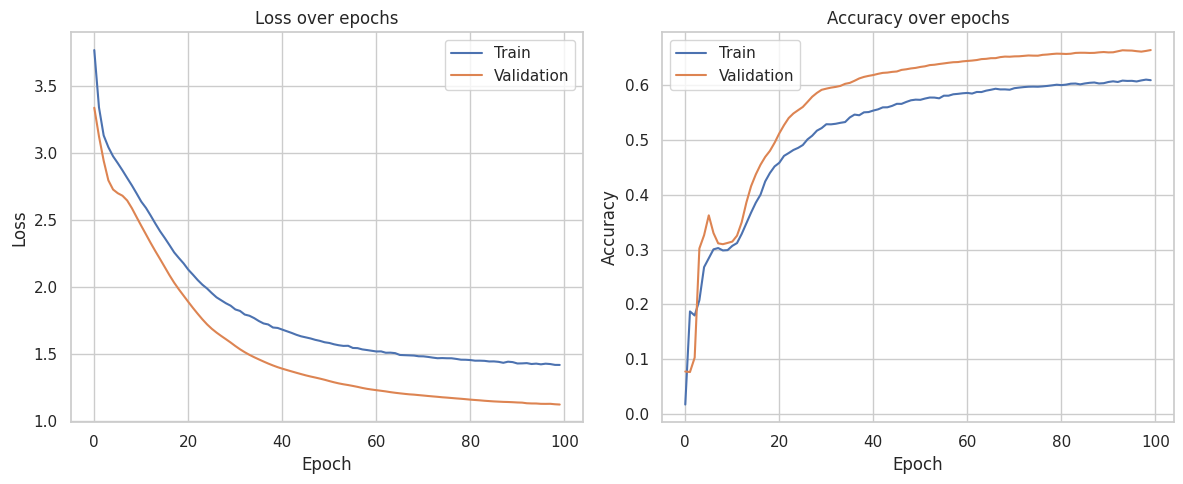

In [25]:
plot_training_history(history)

Bazowy model GAT osiągnął wyniki porównywalne z poprzednimi modelami - ok. 66% skuteczności na zbiorze testowym. Widać przekątną macierzy pomyłek i poprawne krzywe procesu nauki, nie wystąpił overfitting ani underfitting. Dalej problematyczne są mniej licznie reprezentowane klasy, najliczniejsze osiągnęły niemal 90% *accuracy*.

### AdvancedGAT

Aby wykorzystać w pełni potencjał mechanizmu uwagi zdecydowano się na stworzenie bardziej rozbudwanej struktury GAT:

- zmiana komórek `GATConv` na `GATv2Conv` wprowadzające uwagę dynamiczną,
- dodanie warstwy z połączeniem rezydualnym,
- wprowadzenie normalizacji warstw.

Pozostawiono także wysoki dropout. Model trenowano przez 150 epok.

In [76]:
class AdvancedGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=4, out_channels=40, num_layers=3, dropout=0.3):
        super().__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        
        self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout))
        self.norms.append(LayerNorm(hidden_channels * heads))
        
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))
            self.norms.append(LayerNorm(hidden_channels * heads))
            
        self.convs.append(GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout))

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        for i in range(self.num_layers - 1):
            identity = x
            
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.elu(x)
            
            if i > 0:
                x = x + identity
                
            x = F.dropout(x, p=self.dropout, training=self.training)
            
        x = self.convs[-1](x, edge_index)
        return x

In [77]:
model_adv_gat = AdvancedGAT(
    in_channels=dataset.num_features, 
    hidden_channels=64,
    heads=2, 
    out_channels=dataset.num_classes,
    num_layers=3,
    dropout=0.4
)

In [78]:
y_pred, y_prob, history = train_and_eval_gnn(
    model_adv_gat, 
    "AdvancedGAT", 
    epochs=150, 
    lr=0.005
)

Epoch: 001 | Train Loss: 5.8322 | Train Acc: 0.0151 || Val Loss: 3.4811 | Val Acc: 0.0773
Epoch: 005 | Train Loss: 3.4696 | Train Acc: 0.1921 || Val Loss: 2.9133 | Val Acc: 0.1821
Epoch: 010 | Train Loss: 3.0404 | Train Acc: 0.2520 || Val Loss: 2.4992 | Val Acc: 0.3142
Epoch: 015 | Train Loss: 2.7650 | Train Acc: 0.3013 || Val Loss: 2.3366 | Val Acc: 0.3556
Epoch: 020 | Train Loss: 2.5124 | Train Acc: 0.3489 || Val Loss: 2.0470 | Val Acc: 0.4226
Epoch: 025 | Train Loss: 2.2724 | Train Acc: 0.4098 || Val Loss: 1.8136 | Val Acc: 0.5391
Epoch: 030 | Train Loss: 2.0911 | Train Acc: 0.4597 || Val Loss: 1.5890 | Val Acc: 0.5694
Epoch: 035 | Train Loss: 1.9607 | Train Acc: 0.4962 || Val Loss: 1.4794 | Val Acc: 0.5866
Epoch: 040 | Train Loss: 1.8579 | Train Acc: 0.5130 || Val Loss: 1.3738 | Val Acc: 0.6096
Epoch: 045 | Train Loss: 1.7770 | Train Acc: 0.5308 || Val Loss: 1.2990 | Val Acc: 0.6261
Epoch: 050 | Train Loss: 1.7085 | Train Acc: 0.5459 || Val Loss: 1.2561 | Val Acc: 0.6291
Epoch: 055

In [79]:
calculate_metrics("AdvancedGAT", y_pred, y_prob)
metrics["AdvancedGAT"]

{'accuracy': 0.6843610476719544,
 'precision': 0.5160858048281447,
 'recall': 0.4066355621316264,
 'f1': 0.4221308027126865,
 'roc_auc': np.float64(0.9612392462417036)}

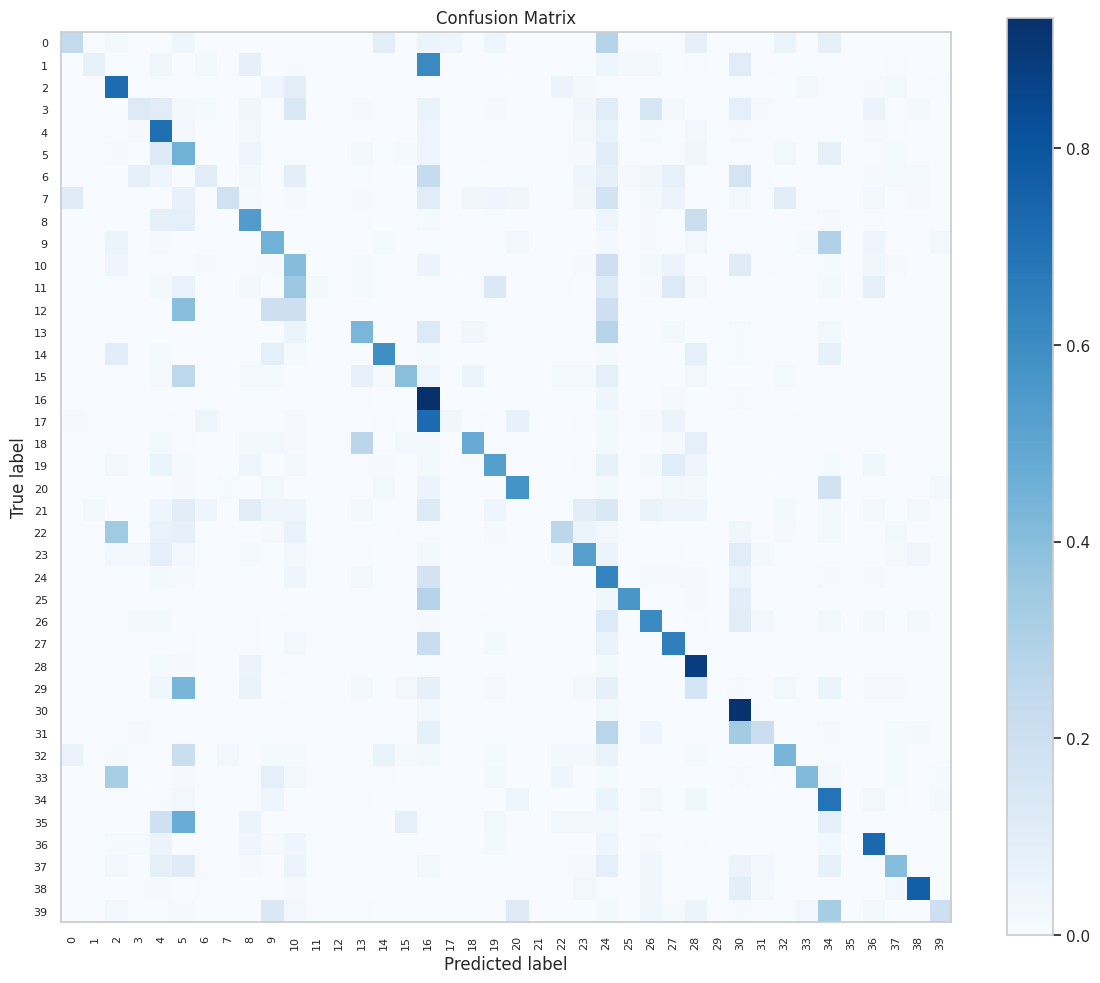

In [22]:
plot_confusion_matrix(y_pred)

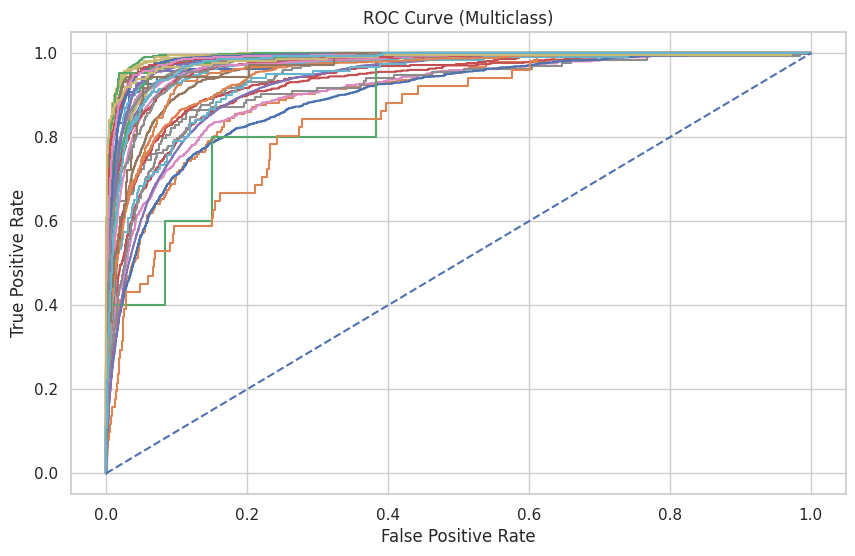

In [23]:
plot_roc_curve(y_prob)

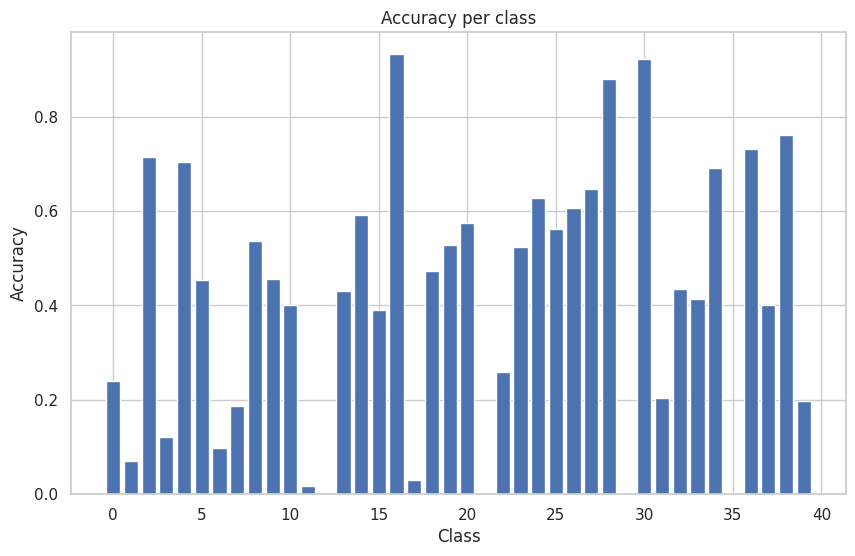

In [24]:
accuracy_per_class(y_pred)

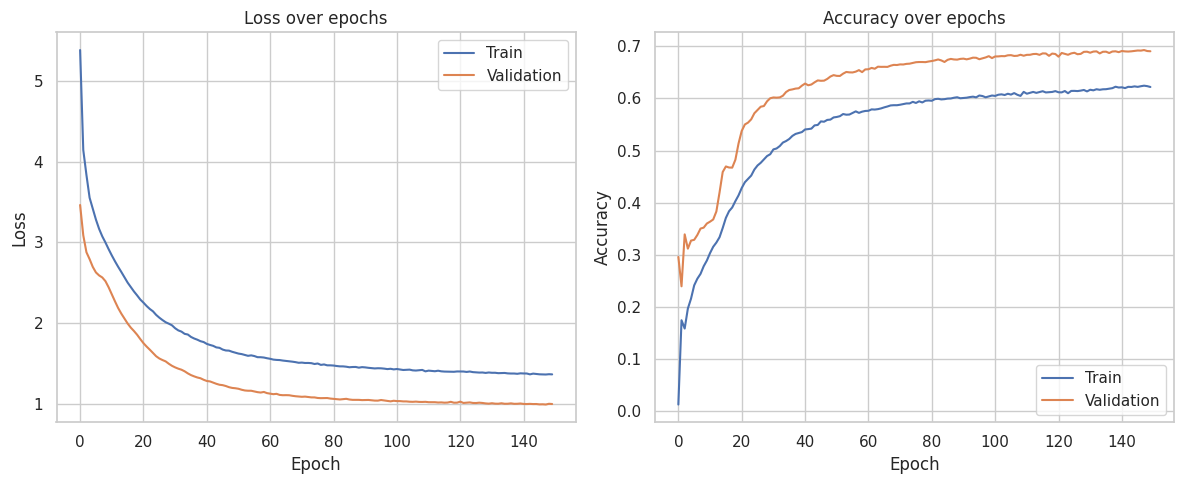

In [25]:
plot_training_history(history)

Odpowiednio rozbudowana sieć atencyjna GAT osięgnęła jedne z najwyższych wyników osiągając 70% skuteczności. Krzywe historii nauki pokazują stabilny proces z jedynie lekkimi fluktuacjami na samym początku nauki, nie wystąpił overfitting ani underfitting. Macierz pomyłek na dobrze zarysowaną główną przekątną, krzywe ROC AUC w dość dobrym tempie zbiegają do zadowalającego poziomu. Skuteczności w poszczególnych klasach są bardzo zróżnicowane - od blisko zera do niemal 90%, zależy to głównie od liczności klas. Model ten można uznać za jeden z najlepszych.

### GRNN - Gated Graph Neural Network

Gated Graph Sequence Neural Network pożycza architekturę bramkową (GRU) znaną z przetwarzania tekstu i szeregów czasowych. Zamiast budować piramidę z nowych warstw, posiada jedną komórkę pamięci (GRU cell), która jest aplikowana wielokrotnie (w pętli) po kroku czasu. W każdym kroku komórka pochłania sygnał od sąsiadów i decyduje, jak zaktualizować wewnętrzny stan wierzchołka.

Kluczowe hiperparametry:

- `num_layers`: określa liczbę iteracji pętli GRU, a nie liczbę odrębnych warstw fizycznych,
- kształt wymiarów.

In [80]:
class GatedGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3):
        super().__init__()
        self.lin_in = torch.nn.Linear(in_channels, hidden_channels)
        
        self.conv = GatedGraphConv(hidden_channels, num_layers=num_layers)
        
        self.lin_out = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = 0.5

    def forward(self, x, edge_index):
        x = self.lin_in(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv(x, edge_index)
        
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin_out(x)
        return x

In [85]:
model_grnn = GatedGNN(dataset.num_features, 128, dataset.num_classes, num_layers=3)

In [86]:
y_pred, y_prob, history = train_and_eval_gnn(model_grnn, "GRNN", epochs=100, lr=0.005)

Epoch: 001 | Train Loss: 3.6495 | Train Acc: 0.0516 || Val Loss: 3.4003 | Val Acc: 0.1424
Epoch: 005 | Train Loss: 3.1553 | Train Acc: 0.1713 || Val Loss: 2.9835 | Val Acc: 0.0763
Epoch: 010 | Train Loss: 3.0973 | Train Acc: 0.1640 || Val Loss: 2.9436 | Val Acc: 0.0763
Epoch: 015 | Train Loss: 3.0347 | Train Acc: 0.1788 || Val Loss: 2.9182 | Val Acc: 0.0763
Epoch: 020 | Train Loss: 3.0384 | Train Acc: 0.1816 || Val Loss: 2.9067 | Val Acc: 0.0957
Epoch: 025 | Train Loss: 2.9525 | Train Acc: 0.1922 || Val Loss: 2.8439 | Val Acc: 0.0826
Epoch: 030 | Train Loss: 2.9378 | Train Acc: 0.2068 || Val Loss: 2.8244 | Val Acc: 0.0805
Epoch: 035 | Train Loss: 2.7614 | Train Acc: 0.2517 || Val Loss: 2.7143 | Val Acc: 0.3025
Epoch: 040 | Train Loss: 2.6352 | Train Acc: 0.2990 || Val Loss: 2.4935 | Val Acc: 0.3076
Epoch: 045 | Train Loss: 2.4982 | Train Acc: 0.3209 || Val Loss: 2.3334 | Val Acc: 0.3762
Epoch: 050 | Train Loss: 2.3814 | Train Acc: 0.3518 || Val Loss: 2.2381 | Val Acc: 0.4119
Epoch: 055

In [87]:
calculate_metrics("GRNN", y_pred, y_prob)
metrics["GRNN"]

{'accuracy': 0.5476410921136555,
 'precision': 0.16120648450352892,
 'recall': 0.18735560791343792,
 'f1': 0.16322330732527682,
 'roc_auc': np.float64(0.8977851510920051)}

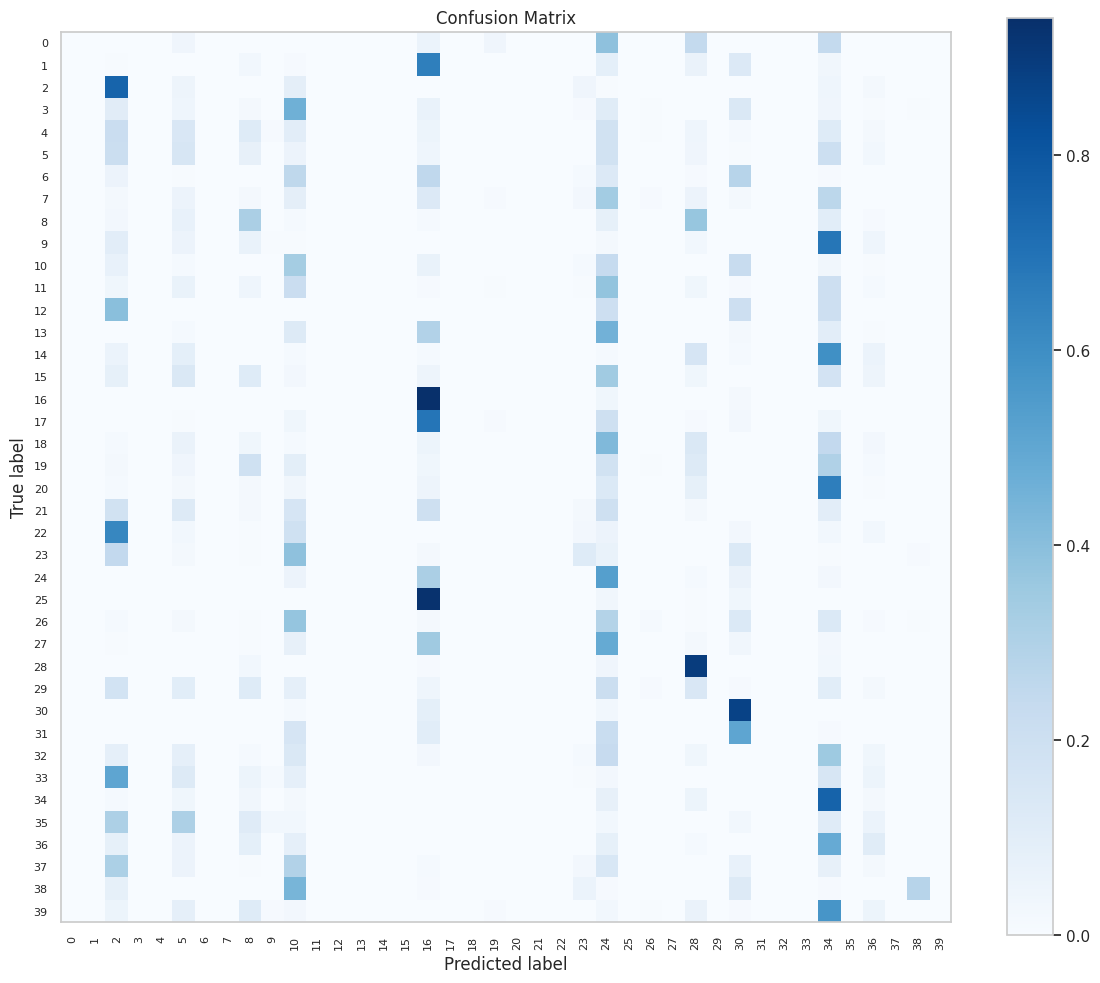

In [20]:
plot_confusion_matrix(y_pred)

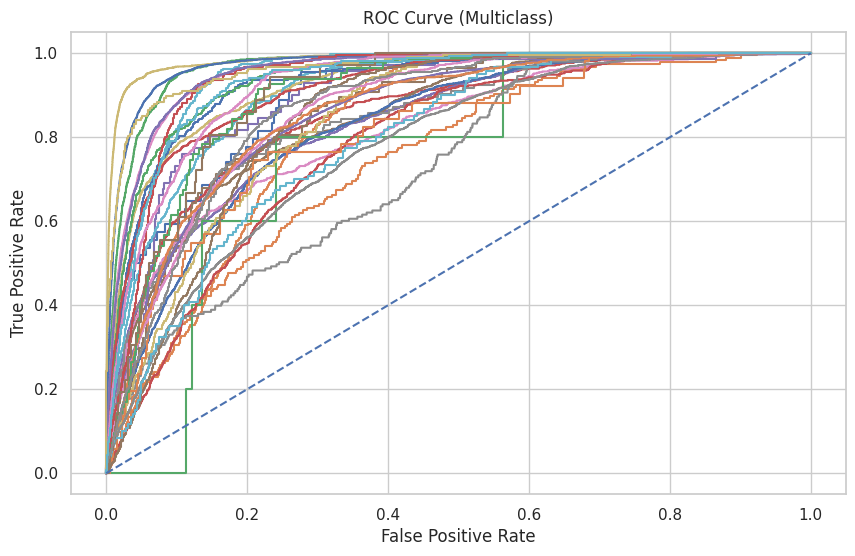

In [21]:
plot_roc_curve(y_prob)

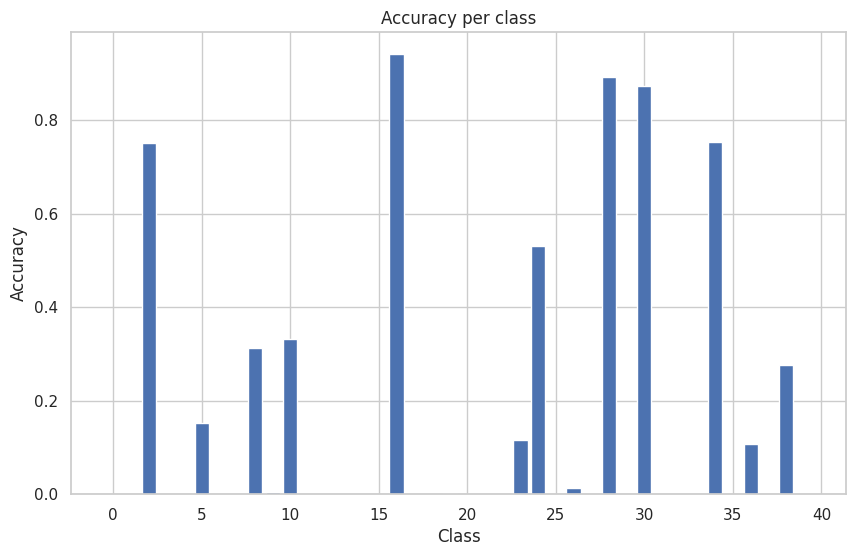

In [22]:
accuracy_per_class(y_pred)

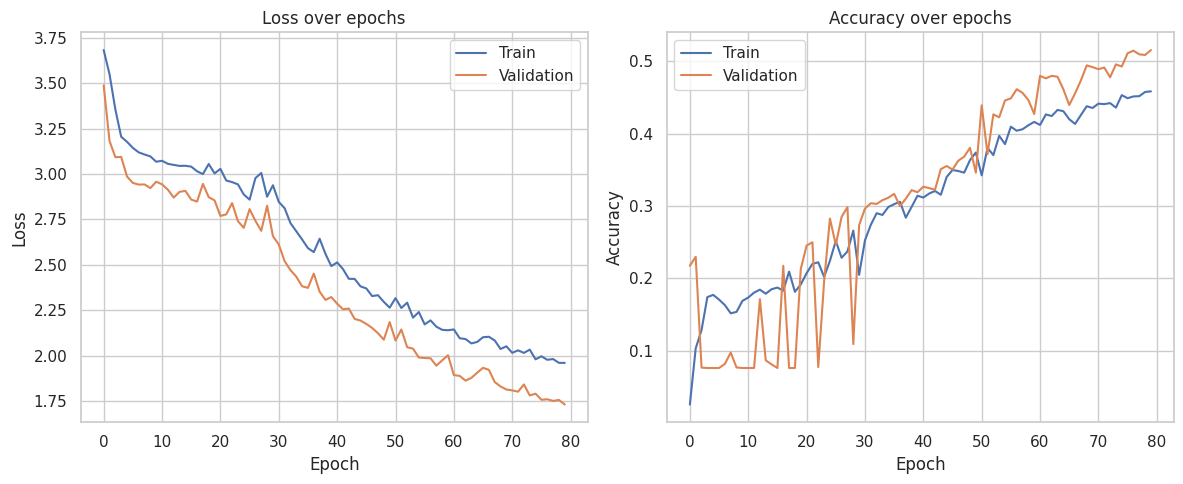

In [23]:
plot_training_history(history)

Model rekurencyjny z komórkami GRU osiągnął najsłabsze wyniki spośród wszystkich modeli grafowych. Skuteczność ledwo przekraczająca poziom 50% to wynik gorszy nawet od MLP nie uwzględniającego struktury grafowej. Problemy widoczne są na wszystkich powyższych wykresach - widać dużą liczbę błędnych predykcji na macierzy pomyłek, bardzo łagodne krzywe ROC AUC, zbyt wiele klas z 0% *acc* oraz dużo fluktuacji i wahań podczas nauki.

### AdvancedGRNN

Celem poprawy osiągów poprzednia struktura została rozbudowana w ciąg oddzielnych warstw, pomiędzy którymi umieszczono mostki rezydualne, aktywacje i normowanie.

In [26]:
class AdvancedGatedGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.3):
        super().__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.lin_in = Linear(in_channels, hidden_channels)
        
        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        
        for _ in range(num_layers):
            self.convs.append(GatedGraphConv(hidden_channels, num_layers=1))
            self.norms.append(LayerNorm(hidden_channels))
            
        self.lin_out = Linear(hidden_channels, out_channels)
        self.relu = ReLU()

    def forward(self, x, edge_index):
        x = self.lin_in(x)
        x = self.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        for i in range(self.num_layers):
            identity = x
            
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = self.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
            x = x + identity
            
        x = self.lin_out(x)
        return x

In [88]:
model_adv_grnn = AdvancedGatedGNN(
    in_channels=dataset.num_features, 
    hidden_channels=128, 
    out_channels=dataset.num_classes, 
    num_layers=3,
    dropout=0.3
)

In [89]:
y_pred, y_prob, history = train_and_eval_gnn(
    model_adv_grnn, 
    "Advanced-GatedGNN", 
    epochs=80, 
    lr=0.005
)

Epoch: 001 | Train Loss: 4.8849 | Train Acc: 0.0376 || Val Loss: 4.0395 | Val Acc: 0.0763
Epoch: 005 | Train Loss: 3.3944 | Train Acc: 0.1147 || Val Loss: 3.0126 | Val Acc: 0.0873
Epoch: 010 | Train Loss: 3.1061 | Train Acc: 0.1906 || Val Loss: 2.7919 | Val Acc: 0.2666
Epoch: 015 | Train Loss: 2.8762 | Train Acc: 0.2558 || Val Loss: 2.6178 | Val Acc: 0.2991
Epoch: 020 | Train Loss: 2.6272 | Train Acc: 0.3030 || Val Loss: 2.2877 | Val Acc: 0.3772
Epoch: 025 | Train Loss: 2.3683 | Train Acc: 0.3578 || Val Loss: 2.0276 | Val Acc: 0.4363
Epoch: 030 | Train Loss: 2.1776 | Train Acc: 0.3946 || Val Loss: 1.8699 | Val Acc: 0.4761
Epoch: 035 | Train Loss: 2.0385 | Train Acc: 0.4319 || Val Loss: 1.7450 | Val Acc: 0.5112
Epoch: 040 | Train Loss: 1.9095 | Train Acc: 0.4619 || Val Loss: 1.6509 | Val Acc: 0.5375
Epoch: 045 | Train Loss: 1.8091 | Train Acc: 0.4887 || Val Loss: 1.5473 | Val Acc: 0.5619
Epoch: 050 | Train Loss: 1.7174 | Train Acc: 0.5140 || Val Loss: 1.4616 | Val Acc: 0.5827
Epoch: 055

In [90]:
calculate_metrics("AdvancedGRNN", y_pred, y_prob)
metrics["AdvancedGRNN"]

{'accuracy': 0.6324712466308664,
 'precision': 0.4236841539313806,
 'recall': 0.33107261744546435,
 'f1': 0.33281845074882455,
 'roc_auc': np.float64(0.9508674882243969)}

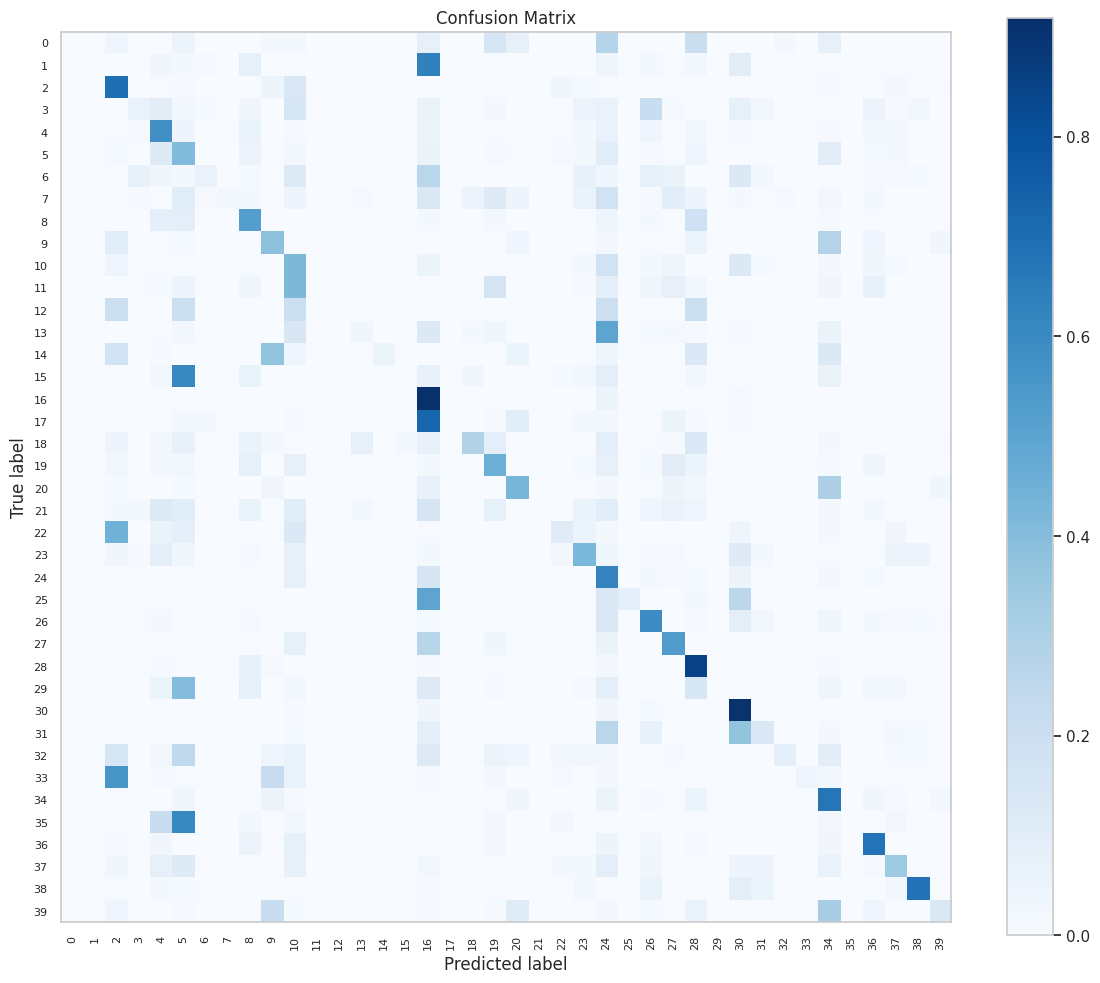

In [30]:
plot_confusion_matrix(y_pred)

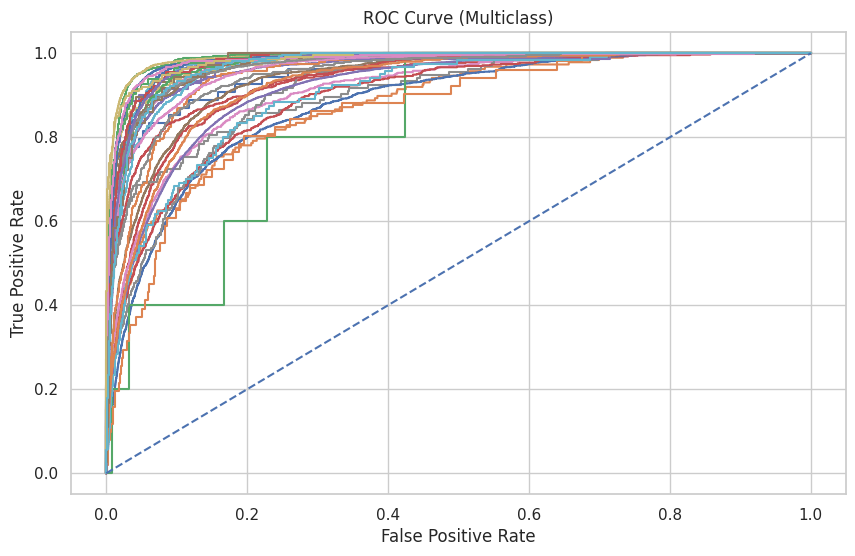

In [31]:
plot_roc_curve(y_prob)

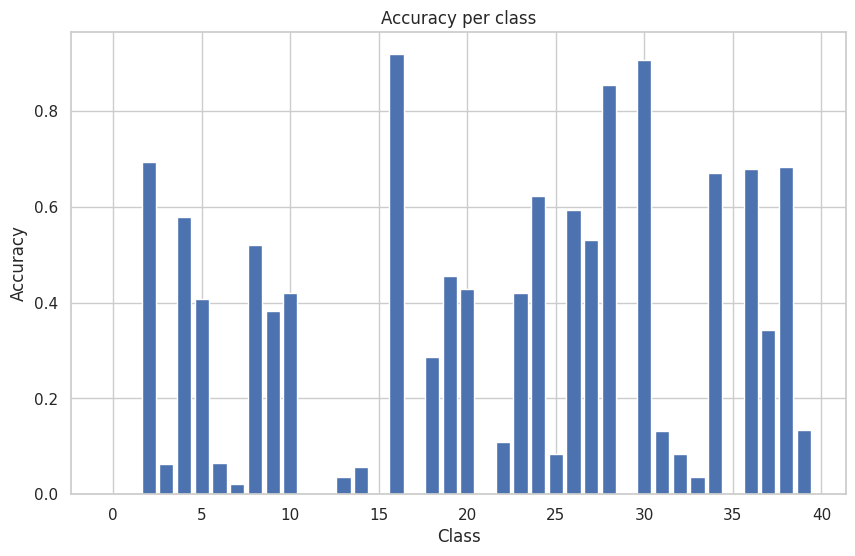

In [32]:
accuracy_per_class(y_pred)

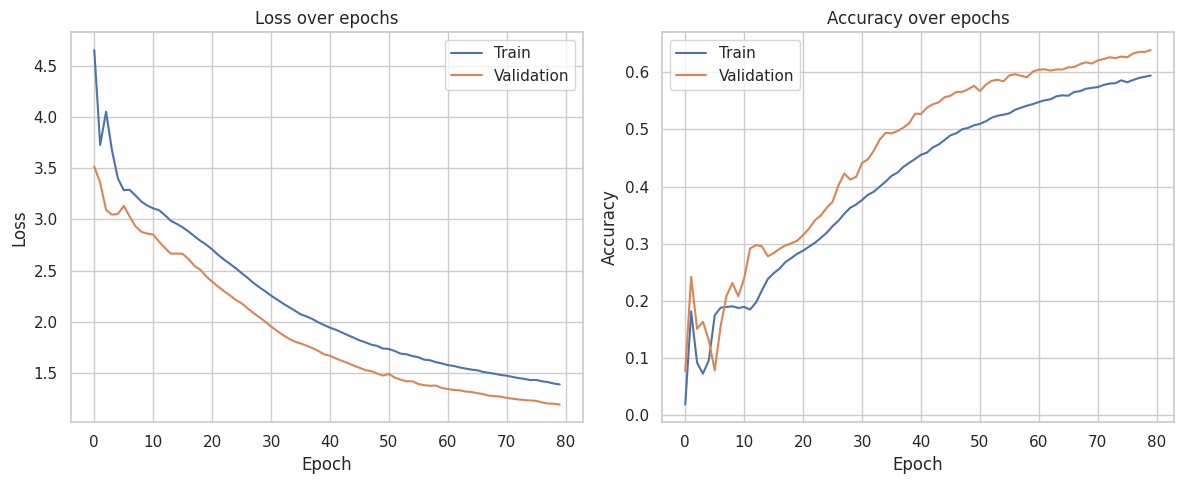

In [33]:
plot_training_history(history)

Powyższe statystyki i wykresy wskazują na dużą poprawę ulepszonego modelu względem jego podstawowej wersji. Wynik na poziomie ogólnego *accuracy* równego 66% na zbiorze testowym w przypadku tego zbioru danych jest już całkiem zadowalający.  Krzywe uczenia wskazują na stopniową, stabilną naukę, mimo początkowych wahań. Macierz błędów ma zarysowaną główną przekątną, poprawiła się także skuteczność modelu w poszczególnych klasach.

### Podsumowanie

In [91]:
df = pd.DataFrame(metrics)
df.T

,accuracy,precision,recall,f1,roc_auc
GCN,0.658601,0.512969,0.371661,0.392564,0.956907
AdvancedGCN,0.695718,0.551024,0.491117,0.498346,0.966797
SAGE,0.671708,0.511175,0.406235,0.425508,0.959951
AdvancedSAGE,0.684299,0.505692,0.426202,0.438039,0.968724
GAT,0.657120,0.475450,0.351485,0.370596,0.955952
AdvancedGAT,0.684361,0.516086,0.406636,0.422131,0.961239
GRNN,0.547641,0.161206,0.187356,0.163223,0.897785
AdvancedGRNN,0.632471,0.423684,0.331073,0.332818,0.950867


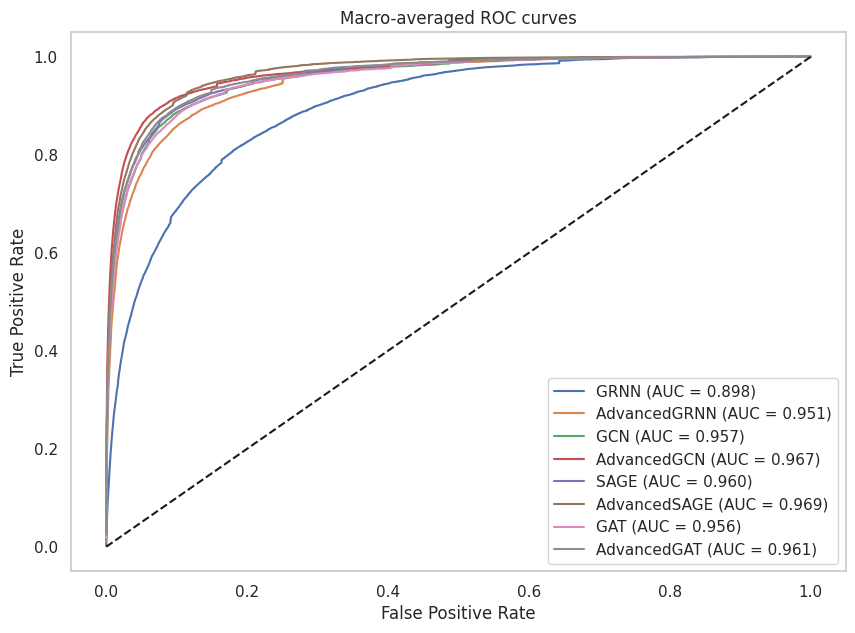

In [92]:
plot_compared_roc()

Jak widać na powyższych statystykach i wykresie, modele grafowe zdecydowanie pobiły proste modele uczenia maszynowego i głębokiego poprawiając ich wyniki o ok. 20pp. Najlepszy wyszkolony model (AdvacedSAGE) uzyskał wynik na poziomie *accuracy* 70%. W świetle trudności wybranego zbioru i faktu, że topowe modele uzyskały na nim co najwyżej 77.2% *accuracy*, wyniki te są więcej niż zadowalające (wszystkie z najlepszych światowych modeli korzystają z rozszerzeń GNN o np. LLM czy C&S). Pojawiały się pewne trudności ze stabilnością procesu nauki, jednak po odpowiednim strojeniu hiperparametrów udało się te problemy pokonać i zapewnić dobre warunki do nauki modeli.

## Podsumowanie

Wybrany grafowy zbiór danych **OGBN-ArXiv** okazał się być niemałym wyzwaniem. Pokazują to wartości metryk skuteczności modeli uczenia maszynowego topowych, światowych rezultatów, które nie przekroczyły jak dotąd 80% (najlepszy wynik to obecnie 77.2%).

Wiele trudności, takich jak brak zbalansowania klas, niezbyt wysoki wskaźnik homofilii czy bardzo różne stopnie wierzchołków, udało się zaobserwować podczas początkowej analizy zbioru danych (EDA). Problemy te przedstawiono także w formie graficznej.

Proste modele uczenia maszynowego - RandomForest, XGBoost i MultiLayerPerceptron - osiągnęły mierne wyniki, najlepszy z nich to 55% skuteczności na zbiorze testowym. Bazowały one jednak wyłącznie na wektorach cech znajdujących się w wierzchołkach grafu, ignorując kompletnie jego strukturę. Widać więc wyraźnie, że jest to duże uproszczenie istoty problemu, które w praktyce uniemożliwia uzyskanie wyższych, zadowalających wyników.

Stworzone w dalszej części miniprojektu modele grafowe - GCN, SAGE, GAT i GRNN - zdecydowanie przewyższyły modele baseline uzyskując wyniki na poziomie ok. 65% *accuracy*. Korzystając z pełnej informacji drzemiącej w strukturze grafowej danych bez trudu pokonały modele bazujące tylko na wektorach cech artykułów. Wykonane dalej modele rozszerzone - Advanced - uzyskały skuteczność na poziomie 70%, co śmiało można uznać za bardzo zadowalące wyniki. Pokazuje to wagę odpowiedniego doboru struktury sieci oraz strojenia hiperparametrów.

Czwarty miniprojekt pozwolił mi w znaczący sposób poszerzyć wiedzę na temat grafowych sieci neuronowych i pracy z danymi o strukturze grafowej. Mimo wysokiej trudności wybranego zbioru danych udało się wytrenować klasyfikatory dające bardzo przyzwoite rezultaty (*accuracy* ok. 70%), zwłaszcza zważywszy na trudność wybranego zbioru danych.
